# **EGD Project**

---

## **1. Introduction**

### **1.1. Problem Description**

The NYC Taxi and Limousine Commission (TLC) has been releasing trip records of the city's entire taxi fleet since 2009. Each record includes pickup/drop-off times and locations, trip distance, fare components, payment method and passenger count.

This project focuses on the Yellow Taxi Trip Records of 2020, a year that captures an unprecedented disruption in urban mobility. The COVID-19 outbreak and the lockdown measures imposed in mid-March caused taxi ridership in NYC to drop by over 80% during the peak of the pandemic, with the number of active drivers falling from ~108k to ~30k between March and June. The 2020 data therefore should contain three distinct mobility regimes within a single year: a pre-pandemic baseline (Jan–Feb), a sharp collapse (Mar–Apr) and a slow partial recovery (rest of the year).

From a data engineering point of view, the dataset is large enough (tens of millions of records across 12 monthly Parquet files) to justify the use of a distributed framework such as Apache Spark and it contains typical big-data challenges (missing values, inconsistent records, outliers).


### **1.2. Objectives**

1. **Descriptive and pattern analysis —** temporal, geographic and trip-level queries over the dataset, with particular attention to pre vs during-pandemic patterns.
2. **ML pipeline —** predictive modelling using Spark MLlib.
3. **Performance evaluation —** runtime analysis using different numbers of computing nodes.

---

## **2. Related Work**

The NYC TLC dataset has been widely used in both academia and industry as a benchmark for big-data and urban mobility studies. The most relevant prior work are grouped in three categories:

**1. Descriptive and pattern analysis with Spark**    
Several projects use PySpark to explore taxi trip records, typically focusing on temporal patterns (peak hours, weekday vs weekend), geographic hotspots and fare distributions. Notable examples include a PySpark analysis of 60M+ trips from 2018 executed on a GCP Spark cluster [1], and a Scala/Spark study of 2017–2022 trips totalling ~5.8 GB [2]. Both apply distributed filtering and aggregation to clean and characterise the data, confirming Spark's suitability for the scale of the TLC dataset.

**2. Predictive modelling on TLC data**   
Predicting fare amount, tip, trip duration or drop-off location has been a recurrent task. Hartanto et al. [3] compare OLS and L-BFGS regression for fare prediction on 12M+ 2023 trips using Spark over HDFS, evaluating models with RMSE/MSE. From a longer-horizon perspective, Singh and Kumar [4] develop a time-series analysis (ARIMA, AR(1)) of daily passenger counts from 2017–2019, reporting a consistent linear decline of ~200 passengers/day even before the pandemic — a relevant baseline for contextualising 2020. These works inform the feature set (trip distance, passenger count, pickup zone, time of day) and evaluation metrics adopted in this project.

**3. COVID-19 impact on NYC taxi demand**   
Two works are particularly relevant. Beecham et al. [5] compare taxi demand across land-use zones between 2019 and 2020, reporting a redistribution of trips towards residential areas and a significant increase in cash payments during the pandemic — counter to public-health guidance. Yang et al. [6] apply a Geographically and Temporally Weighted Regression (GTWR) model to TLC data from Aug 2020–Jul 2021 to quantify the spatio-temporal impact of COVID-19 case rates on taxi demand. Official figures from the NYC Taxi & Limousine Commission [7] report that the number of working drivers fell from 108,880 to 30,675 between March and June 2020 (-71%), with daily yellow taxi trips dropping from ~200k in February to ~18k in June — a tenfold reduction. A later IBO study [8] further shows that, even years after the initial shock, yellow taxi trips in Manhattan remained at roughly 50% of pre-pandemic levels.


### **2.1. References**
[1] Alpha-1787, "PySpark NYC Taxi Trips Analysis", GitHub repository, 2020. [Online]. Available: https://github.com/Alpha-1787/PySpark-NYC-Taxi-Trips-Analysis

[2] C. Vivieca, "NYC Yellow Taxi Analysis with Apache Spark and Scala", GitHub repository, 2023. [Online]. Available: https://github.com/cvivieca/nyc-yellow-taxi-analysis

[3] S. Rhouas, and N. El Hami, "Analysis of big data from New York taxi trip 2023: revenue prediction using ordinary least squares solution and limited-memory Broyden-Fletcher-Goldfarb-Shanno algorithms", International Journal of Electrical and Computer Engineering, 2025. [Online]. Available: https://www.researchgate.net/publication/388598301

[4] G. Singh, "Forecasting NYC Yellow Taxi Ridership Decline: A Time Series Analysis of Daily Passenger Counts (2017-2019)", arXiv preprint arXiv:2507.10588, 2025. [Online]. Available: https://arxiv.org/abs/2507.10588

[5] E. Manley, S. Ross, and M. Zhuang, "Changing Demand for New York Yellow Cabs during the COVID-19 Pandemic", Findings, 2021. [Online]. Available: https://findingspress.org/article/22158

[6] Y. Zhang, X. Sui, and S. Zhang, "Exploring spatio-temporal impact of COVID-19 on citywide taxi demand: A case study of New York City", PLOS ONE, vol. 19, no. 4, 2024. [Online]. Available: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0299093

[7] New York City Taxi & Limousine Commission, "2020 TLC Factbook", 2020. [Online]. Available: https://www.nyc.gov/assets/tlc/downloads/pdf/2020-tlc-factbook.pdf

[8] New York City Independent Budget Office, "Fare Play: Considerations for Exempting Yellow Taxis From a Congestion Pricing Surcharge," 2024. Reported in: N. Garber, "Hails In Half: Yellow Cab Trips At 50% Of Pre-COVID Levels, Study Says", Patch, Feb. 2024. [Online]. Available: https://patch.com/new-york/new-york-city/hails-half-yellow-cab-trips-50-pre-covid-levels-study-says

---

## **3. Dataset Profiling**

### **3.1. Collect Initial Data**

**Source:**   
NYC Taxi & Limousine Commission (TLC) — *Yellow Taxi Trip Records*, year **2020**. Originally published by the TLC at https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page and re-distributed on Kaggle by Marc Brandner:  
https://www.kaggle.com/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/data

**Storage:**  
- *Local development:* `./data/2020/`  

**Format:**   
- Apache Parquet

**Issues encountered during loading:**  
- The `airport_fee` column only became populated from 2022 onward, but it appears in the schema with `null` values throughout 2020. We retain it during loading and will drop it in the cleaning step.

**Initial actions:**  
1. Load the 12 Parquet files into a single Spark DataFrame with an explicit schema.  
2. Join with `taxi_zone_lookup.csv` (broadcast join, since the lookup is small) to add `Borough` and `Zone` for both pickup and dropoff locations.

In [1]:
LOCAL = True

**Libraries**

In [ ]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
import numpy as np
import seaborn as sns
from pyspark.sql.functions import (
    col, count, when, isnan,
    countDistinct,
    sum as _sum,
    unix_timestamp,
    count as spark_count,
    abs as spark_abs,
    hour, dayofweek, month, dayofmonth, weekofyear, to_date, date_trunc,
    avg,
    concat, lit,
    year
)
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch
import matplotlib.dates as mdates
import math
import geopandas as gpd

**Spark Session**

In [3]:
from pyspark.sql import SparkSession
if LOCAL:
  spark = SparkSession.builder.master("local[*]").appName("NYC_Taxi_Analysis").config("spark.driver.memory", "8g").getOrCreate()
else:
  spark = SparkSession.builder.appName("NYC_Taxi_Analysis").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/14 01:22:36 WARN Utils: Your hostname, MacBook-Pro-de-Luana.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.172 instead (on interface en0)
26/05/14 01:22:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/14 01:22:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**Create taxi_df**

In [4]:
# Data path
if LOCAL:
  DATA_PATH = "./data/2020"
else:
  # O teu bucket no Dataproc
  DATA_PATH = "gs://nyc-taxi-data-27/data"

# Parquet files logic
if LOCAL:
  parquet_files = glob.glob(
    os.path.join(DATA_PATH, "*.parquet")
  )
  print(f"\nFound {len(parquet_files)} parquet files.")

  # Count total rows
  total_rows = 0
  for file in parquet_files:
      parquet_file = pq.ParquetFile(file)
      rows = parquet_file.metadata.num_rows
      print(f"{os.path.basename(file)} -> {rows:,} rows")
      total_rows += rows

  print("\n=========================")
  print(f"TOTAL ROWS: {total_rows:,}")
  print("=========================")
else:
  parquet_path = f"{DATA_PATH}/*.parquet"

# 1. Define explicitly the type of each column (Fixed: Using TimestampType instead of TimestampNTZType)
taxi_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),  # <-- AQUI ESTÁ A CORREÇÃO
    StructField("tpep_dropoff_datetime", TimestampType(), True), # <-- AQUI ESTÁ A CORREÇÃO
    StructField("passenger_count", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True)
])

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 2. Read files
if LOCAL:
  taxi_df = spark.read.schema(taxi_schema).parquet(*parquet_files)
else:
  taxi_df = spark.read.schema(taxi_schema).parquet(parquet_path)

print("\nDataset loaded successfully with explicit schema!")

# Dataset info
print("\n=========================")
print("TOTAL ROWS:", taxi_df.count())
print("TOTAL COLUMNS:", len(taxi_df.columns))
print("=========================")

# Load taxi_zone_lookup.csv
zone_df = spark.read.csv(
    f"{DATA_PATH}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

print("\nTaxi Zone Lookup Preview:")
zone_df.show(5)

# Pickup join
pickup_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "PULocationID")
    .withColumnRenamed("Borough", "PU_Borough")
    .withColumnRenamed("Zone", "PU_Zone")
    .withColumnRenamed("service_zone", "PU_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(pickup_lookup),
    on="PULocationID",
    how="left"
)

print("\nPickup join completed!")

# Dropoff join
dropoff_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "DOLocationID")
    .withColumnRenamed("Borough", "DO_Borough")
    .withColumnRenamed("Zone", "DO_Zone")
    .withColumnRenamed("service_zone", "DO_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(dropoff_lookup),
    on="DOLocationID",
    how="left"
)

print("\nDropoff join completed!")

# Final dataset info
print("\nFinal Schema:")
taxi_df.printSchema()

print("\nFinal Dataset Preview:")
taxi_df.show(5)


Found 12 parquet files.
yellow_tripdata_2020-03.parquet -> 3,007,687 rows
yellow_tripdata_2020-12.parquet -> 1,461,898 rows
yellow_tripdata_2020-02.parquet -> 6,299,367 rows
yellow_tripdata_2020-10.parquet -> 1,681,132 rows
yellow_tripdata_2020-09.parquet -> 1,341,017 rows
yellow_tripdata_2020-08.parquet -> 1,007,286 rows
yellow_tripdata_2020-11.parquet -> 1,509,000 rows
yellow_tripdata_2020-01.parquet -> 6,405,008 rows
yellow_tripdata_2020-04.parquet -> 238,073 rows
yellow_tripdata_2020-05.parquet -> 348,415 rows
yellow_tripdata_2020-07.parquet -> 800,412 rows
yellow_tripdata_2020-06.parquet -> 549,797 rows

TOTAL ROWS: 24,649,092

Dataset loaded successfully with explicit schema!

TOTAL ROWS: 24649092
TOTAL COLUMNS: 19

Taxi Zone Lookup Preview:
+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EW

### **3.2. Describe Data**

#### 3.2.1. Basic structure

In [5]:
n_rows = taxi_df.count()
n_cols = len(taxi_df.columns)

print("=" * 50)
print("DATASET STRUCTURE")
print("=" * 50)
print(f"Number of rows    : {n_rows:,}")
print(f"Number of columns : {n_cols}")
print(f"Granularity       : 1 row = 1 completed taxi trip")
print("=" * 50)

# Files & disk size
if LOCAL:
    total_size_bytes = sum(os.path.getsize(f) for f in parquet_files)
    print(f"Number of files   : {len(parquet_files)}")
    print(f"Total size on disk: {total_size_bytes / (1024**2):.2f} MB "
          f"({total_size_bytes / (1024**3):.2f} GB)")

DATASET STRUCTURE
Number of rows    : 24,649,092
Number of columns : 25
Granularity       : 1 row = 1 completed taxi trip
Number of files   : 12
Total size on disk: 357.25 MB (0.35 GB)


#### 3.2.2. Schema

In [6]:
print("Schema:\n")
taxi_df.printSchema()

Schema:

root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- PU_Borough: string (nullable = true)
 |-- PU_Zone: string (nullable = true)
 |-- PU_service_zone: string (nullable = true)
 |

#### 3.2.3. Variable dictionary

In [7]:
original_columns = pd.DataFrame([
    ("VendorID",              "Categorical (nominal)", "TPEP provider that recorded the trip (1=Creative Mobile Technologies, 2=VeriFone)"),
    ("tpep_pickup_datetime",  "Datetime",              "Date and time when the meter was engaged"),
    ("tpep_dropoff_datetime", "Datetime",              "Date and time when the meter was disengaged"),
    ("passenger_count",       "Numeric (discrete)",    "Number of passengers in the vehicle (driver-entered)"),
    ("trip_distance",         "Numeric (continuous)",  "Elapsed trip distance in miles reported by the taximeter"),
    ("RatecodeID",            "Categorical (nominal)", "Final rate code (1=Standard, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=Negotiated, 6=Group ride)"),
    ("store_and_fwd_flag",    "Categorical (nominal)", "Y/N — whether the trip was held in vehicle memory before sending to the vendor"),
    ("PULocationID",          "Categorical (nominal)", "TLC Taxi Zone in which the taximeter was engaged"),
    ("DOLocationID",          "Categorical (nominal)", "TLC Taxi Zone in which the taximeter was disengaged"),
    ("payment_type",          "Categorical (nominal)", "1=Credit card, 2=Cash, 3=No charge, 4=Dispute, 5=Unknown, 6=Voided"),
    ("fare_amount",           "Numeric (continuous)",  "Time-and-distance fare calculated by the meter (USD)"),
    ("extra",                 "Numeric (continuous)",  "Miscellaneous extras and surcharges ($0.50 and $1 rush hour / overnight charges)"),
    ("mta_tax",               "Numeric (continuous)",  "$0.50 MTA tax automatically triggered based on the metered rate"),
    ("improvement_surcharge", "Numeric (continuous)",  "$0.30 improvement surcharge at the flag drop (since 2015)"),
    ("tip_amount",            "Numeric (continuous)",  "Tip amount — populated for credit card tips only (cash tips not included)"),
    ("tolls_amount",          "Numeric (continuous)",  "Total amount of all tolls paid in the trip"),
    ("total_amount",          "Numeric (continuous)",  "Total amount charged to passengers (does not include cash tips)"),
    ("congestion_surcharge",  "Numeric (continuous)",  "Total amount collected for NYS congestion surcharge"),
    ("airport_fee",           "Numeric (continuous)",  "$1.25 for pickup at LaGuardia and JFK airports (populated from 2022 onwards)"),
], columns=["Variable", "Type", "Description"])

print("Original TLC dataset — 19 columns")
original_columns

Original TLC dataset — 19 columns


,Variable,Type,Description
0,VendorID,Categorical (nominal),TPEP provider that recorded the trip (1=Creati...
1,tpep_pickup_datetime,Datetime,Date and time when the meter was engaged
2,tpep_dropoff_datetime,Datetime,Date and time when the meter was disengaged
3,passenger_count,Numeric (discrete),Number of passengers in the vehicle (driver-en...
4,trip_distance,Numeric (continuous),Elapsed trip distance in miles reported by the...
5,RatecodeID,Categorical (nominal),"Final rate code (1=Standard, 2=JFK, 3=Newark, ..."
6,store_and_fwd_flag,Categorical (nominal),Y/N — whether the trip was held in vehicle mem...
7,PULocationID,Categorical (nominal),TLC Taxi Zone in which the taximeter was engaged
8,DOLocationID,Categorical (nominal),TLC Taxi Zone in which the taximeter was disen...
9,payment_type,Categorical (nominal),"1=Credit card, 2=Cash, 3=No charge, 4=Dispute,..."


In [8]:
enriched_columns = pd.DataFrame([
    ("PU_Borough",      "Categorical (nominal)", "Borough of the pickup zone (joined from taxi_zone_lookup.csv on PULocationID)"),
    ("PU_Zone",         "Categorical (nominal)", "Name of the pickup zone (joined from taxi_zone_lookup.csv on PULocationID)"),
    ("PU_service_zone", "Categorical (nominal)", "Service zone of the pickup (Yellow Zone, Boro Zone, Airports, EWR)"),
    ("DO_Borough",      "Categorical (nominal)", "Borough of the dropoff zone (joined from taxi_zone_lookup.csv on DOLocationID)"),
    ("DO_Zone",         "Categorical (nominal)", "Name of the dropoff zone (joined from taxi_zone_lookup.csv on DOLocationID)"),
    ("DO_service_zone", "Categorical (nominal)", "Service zone of the dropoff"),
], columns=["Variable", "Type", "Description"])

print("Columns added via lookup join — 6 columns")
enriched_columns

Columns added via lookup join — 6 columns


,Variable,Type,Description
0,PU_Borough,Categorical (nominal),Borough of the pickup zone (joined from taxi_z...
1,PU_Zone,Categorical (nominal),Name of the pickup zone (joined from taxi_zone...
2,PU_service_zone,Categorical (nominal),"Service zone of the pickup (Yellow Zone, Boro ..."
3,DO_Borough,Categorical (nominal),Borough of the dropoff zone (joined from taxi_...
4,DO_Zone,Categorical (nominal),Name of the dropoff zone (joined from taxi_zon...
5,DO_service_zone,Categorical (nominal),Service zone of the dropoff


#### 3.2.4. Cardinality of categorical variables

In [9]:
categorical_cols = [
    "VendorID", "passenger_count", "RatecodeID", "store_and_fwd_flag",
    "PULocationID", "DOLocationID", "payment_type",
    "PU_Borough", "DO_Borough", "PU_service_zone", "DO_service_zone"
]

card = taxi_df.select([countDistinct(c).alias(c) for c in categorical_cols]).collect()[0].asDict()
card_df = (
    pd.DataFrame(list(card.items()), columns=["Column", "Distinct values"])
    .sort_values("Distinct values")
    .reset_index(drop=True)
)

# Classify cardinality
def classify(n):
    if n <= 10:
        return "Low"
    elif n <= 50:
        return "Medium"
    else:
        return "High"

card_df["Cardinality"] = card_df["Distinct values"].apply(classify)
print(card_df.to_string(index=False))

            Column  Distinct values Cardinality
store_and_fwd_flag                2         Low
          VendorID                4         Low
   PU_service_zone                5         Low
   DO_service_zone                5         Low
      payment_type                6         Low
        RatecodeID                7         Low
        PU_Borough                7         Low
        DO_Borough                7         Low
   passenger_count               10         Low
      PULocationID              262        High
      DOLocationID              263        High


In [10]:
# Distinct values for low-cardinality columns
low_card_cols = ["store_and_fwd_flag", "VendorID", "PU_service_zone", "DO_service_zone", "payment_type", "RatecodeID", "PU_Borough", "DO_Borough", "passenger_count"]

for c in low_card_cols:
    values = [r[0] for r in taxi_df.select(c).distinct().orderBy(c).collect()]
    print(f"{c:20s} → {values}")

store_and_fwd_flag   → [None, 'N', 'Y']


VendorID             → [1, 2, 5, 6]


PU_service_zone      → ['Airports', 'Boro Zone', 'EWR', 'N/A', 'Yellow Zone']


DO_service_zone      → ['Airports', 'Boro Zone', 'EWR', 'N/A', 'Yellow Zone']
payment_type         → [0, 1, 2, 3, 4, 5]
RatecodeID           → [None, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0]


PU_Borough           → ['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island', 'Unknown']


DO_Borough           → ['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island', 'Unknown']
passenger_count      → [None, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]


#### 3.2.5. Monthly distribution

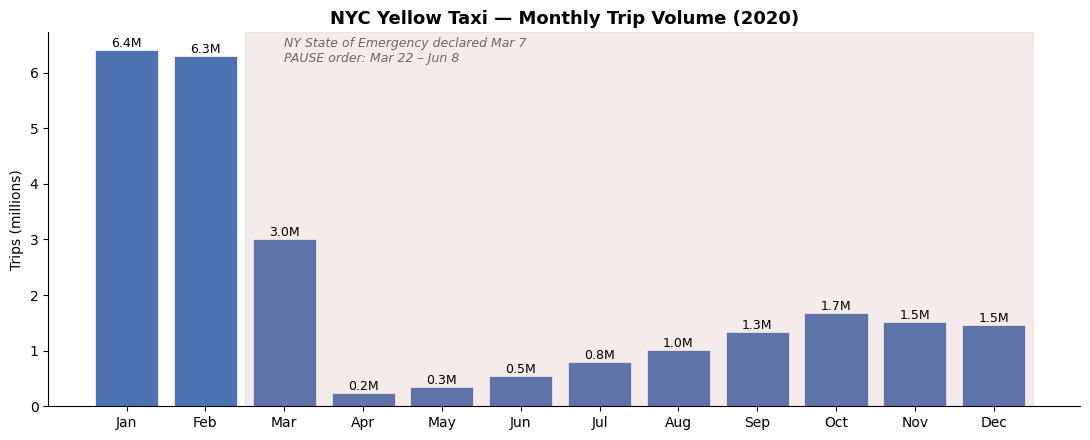

 month   count
     1 6405198
     2 6299493
     3 3007158
     4  237912
     5  348339
     6  549670
     7  799824
     8 1007762
     9 1340368
    10 1682378
    11 1508915
    12 1462075


In [11]:
monthly = (
    taxi_df
    .withColumn("month", month("tpep_pickup_datetime"))
    .filter(col("month").between(1, 12))
    .groupBy("month").count()
    .orderBy("month")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(monthly["month"], monthly["count"] / 1e6, color="#4C72B0",
              edgecolor="white", linewidth=0.5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("Trips (millions)")
ax.set_title("NYC Yellow Taxi — Monthly Trip Volume (2020)", fontsize=13, fontweight="bold")

# Factual contextual annotation
ax.axvspan(2.5, 12.5, alpha=0.15, color="#C97E7E")
ax.text(
    3, ax.get_ylim()[1] * 0.92,
    "NY State of Emergency declared Mar 7\nPAUSE order: Mar 22 – Jun 8",
    fontsize=9, color="dimgrey", style="italic"
)

for bar, val in zip(bars, monthly["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(monthly.to_string(index=False))

### **3.3. Explore Data**

In [12]:
# SETUP — shared variables for all exploration dashboards

# --- Pandemic regimes (used across dashboards) ---
taxi_df_reg = taxi_df.withColumn(
    "regime",
    when(month("tpep_pickup_datetime").isin([1, 2]), "1_pre")
     .when(month("tpep_pickup_datetime").isin([3, 4]), "2_lockdown")
     .when(month("tpep_pickup_datetime").isin([5, 6, 7, 8]), "3_recovery")
     .otherwise("4_late")
)

regime_order  = ["1_pre", "2_lockdown", "3_recovery", "4_late"]
regime_labels = {
    "1_pre":       "Pre-pandemic (Jan–Feb)",
    "2_lockdown":  "Lockdown (Mar–Apr)",
    "3_recovery":  "Recovery (May–Aug)",
    "4_late":      "Late 2020 (Sep–Dec)",
}
regime_palette = {
    "1_pre":      "#4C72B0",
    "2_lockdown": "#C44E52",
    "3_recovery": "#DD8452",
    "4_late":     "#55A868",
}

# --- Sample (1%) for scatter plots / pandas-based analysis ---
sample_cols = [
    "passenger_count", "trip_distance",
    "fare_amount", "tip_amount", "tolls_amount", "total_amount",
    "extra", "congestion_surcharge",
    "payment_type", "RatecodeID", "VendorID",
    "PU_Borough", "DO_Borough", "PULocationID", "DOLocationID",
    "tpep_pickup_datetime", "tpep_dropoff_datetime"
]
sample_df = (
    taxi_df.select(*sample_cols)
    .filter(month("tpep_pickup_datetime").between(1, 12))   # drop OOR
    .sample(fraction=0.01, seed=42)
    .toPandas()
)
sample_df["duration_min"] = (
    sample_df["tpep_dropoff_datetime"] - sample_df["tpep_pickup_datetime"]
).dt.total_seconds() / 60
sample_df["month"]     = sample_df["tpep_pickup_datetime"].dt.month
sample_df["hour"]      = sample_df["tpep_pickup_datetime"].dt.hour
sample_df["dow"]       = sample_df["tpep_pickup_datetime"].dt.dayofweek      # 0=Mon
sample_df["date"]      = sample_df["tpep_pickup_datetime"].dt.date
sample_df["regime"]    = pd.cut(
    sample_df["month"],
    bins=[0, 2, 4, 8, 12],
    labels=regime_order
).astype(str)

print(f"Sample size: {len(sample_df):,} rows ({len(sample_df)/n_rows*100:.2f}% of total)")
sample_df.head(3)

Sample size: 247,478 rows (1.00% of total)


,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,extra,congestion_surcharge,payment_type,RatecodeID,...,PULocationID,DOLocationID,tpep_pickup_datetime,tpep_dropoff_datetime,duration_min,month,hour,dow,date,regime
0,4.0,1.31,7.0,3.24,0.0,14.04,0.5,2.5,1,1.0,...,229,141,2020-03-01 00:54:14,2020-03-01 01:01:15,7.016667,3,0,6,2020-03-01,2_lockdown
1,1.0,2.30,10.5,2.35,0.0,14.15,0.5,0.0,1,1.0,...,181,188,2020-03-01 00:05:37,2020-03-01 00:16:39,11.033333,3,0,6,2020-03-01,2_lockdown
2,1.0,0.75,5.0,1.00,0.0,9.80,0.5,2.5,1,1.0,...,113,234,2020-03-01 00:38:40,2020-03-01 00:42:58,4.300000,3,0,6,2020-03-01,2_lockdown


#### 3.3.1. Descriptive statistics

In [13]:
numeric_cols = ["passenger_count", "trip_distance",
                "fare_amount", "tip_amount", "tolls_amount", "total_amount",
                "extra", "mta_tax", "improvement_surcharge", "congestion_surcharge"]

desc = (
    taxi_df.select(numeric_cols)
    .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
    .toPandas()
    .set_index("summary")
    .T
)
# Convert to float for cleaner display
desc = desc.apply(pd.to_numeric, errors="coerce").round(2)
desc

26/05/14 01:23:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


summary,count,mean,stddev,min,25%,50%,75%,max
passenger_count,23839125,1.47,1.11,0.00,1.00,1.00,1.00,9.00
trip_distance,24649092,3.53,325.03,-30.62,0.99,1.65,3.00,350914.89
fare_amount,24649092,12.67,274.09,-1259.00,6.50,9.00,14.00,998310.03
tip_amount,24649092,2.08,2.61,-493.22,0.00,1.92,2.76,1393.56
tolls_amount,24649092,0.30,1.60,-40.00,0.00,0.00,0.00,925.50
total_amount,24649092,18.42,340.22,-1260.30,11.16,14.30,19.80,1000003.80
extra,24649092,1.07,100.72,-27.00,0.00,0.50,2.50,500000.80
mta_tax,24649092,0.51,100.71,-0.50,0.50,0.50,0.50,500000.50
improvement_surcharge,24649092,0.30,0.04,-0.30,0.30,0.30,0.30,0.30
congestion_surcharge,23839125,2.27,0.75,-2.50,2.50,2.50,2.50,3.00


#### 3.3.2. Distribution dashboard

/var/folders/yp/65klpy9935xg61n4lft7zjrm0000gn/T/ipykernel_9415/3218391605.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


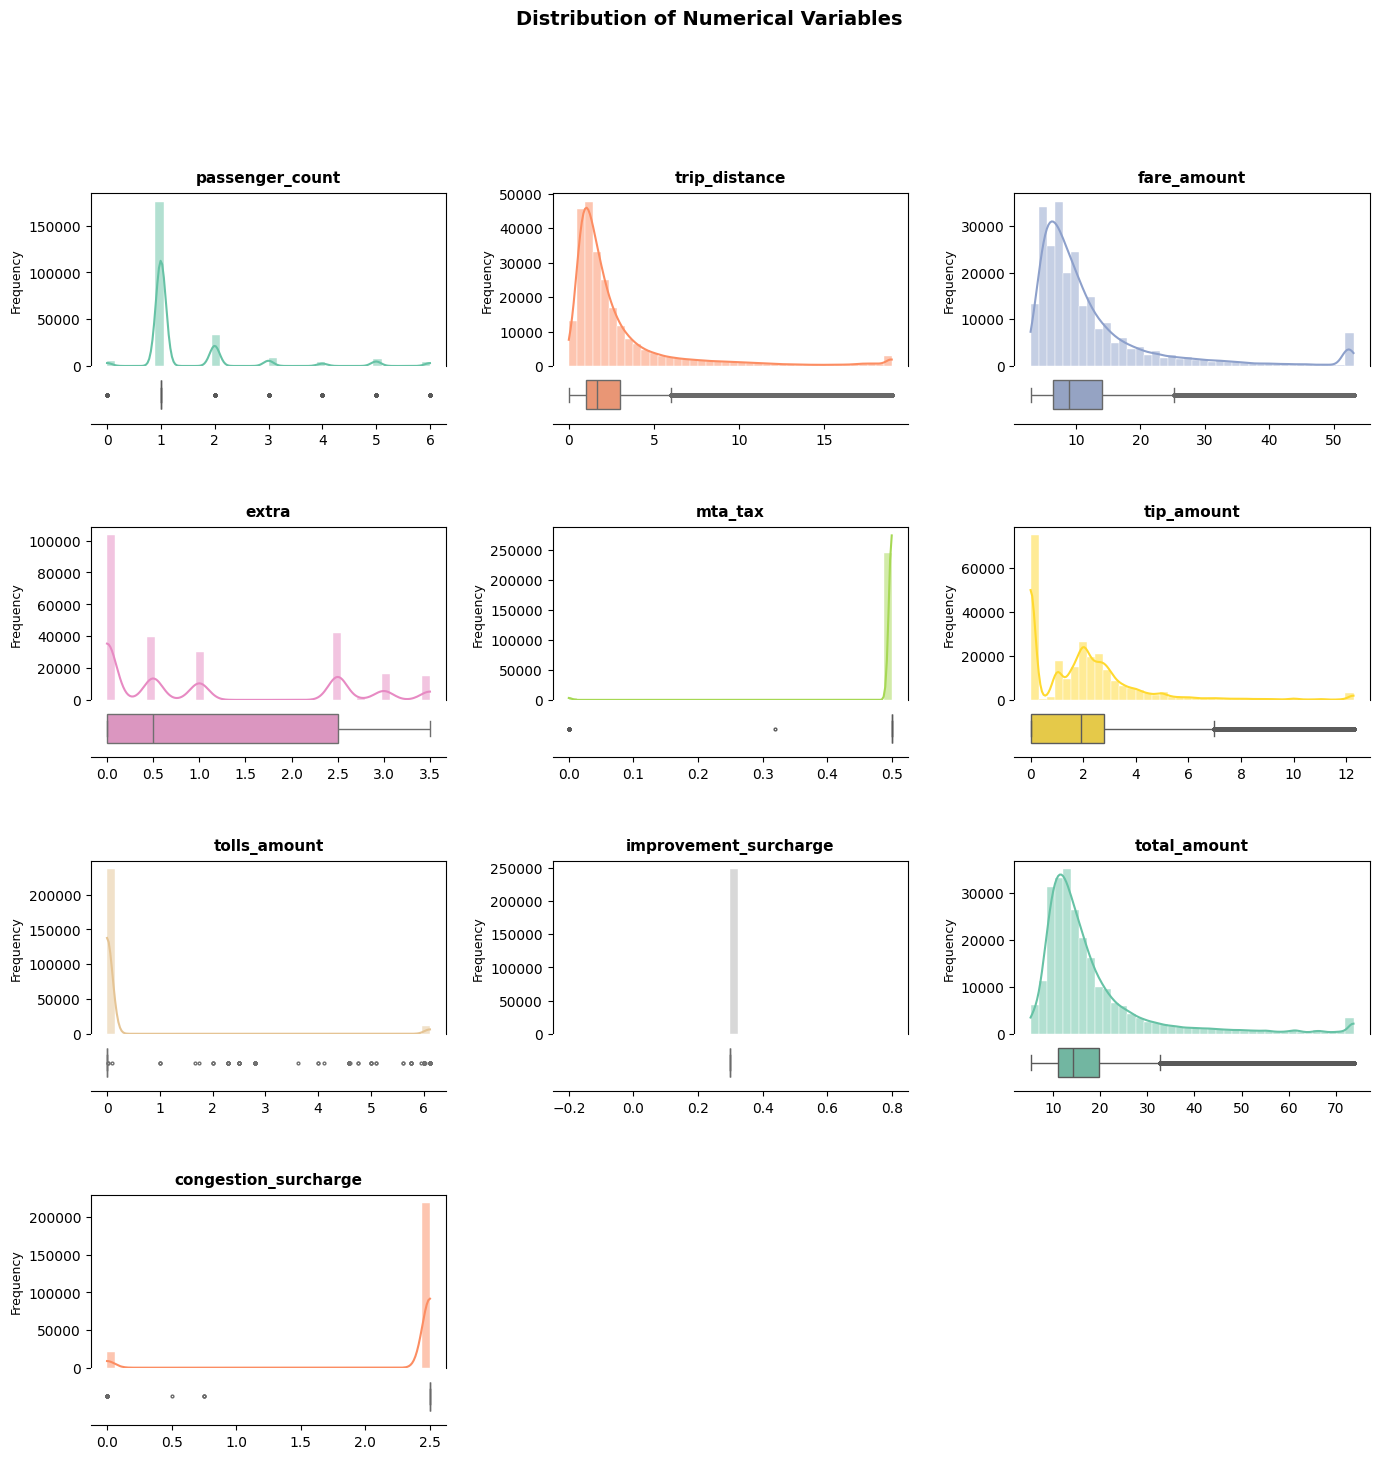

In [14]:
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
]

# Sample
sample = taxi_df.select(*numeric_cols).sample(fraction=0.01, seed=42).toPandas()

# Clip extreme outliers at 1st/99th percentiles for visualisation only
sample_clipped = sample.copy()
for c in numeric_cols:
    lo, hi = sample_clipped[c].quantile([0.01, 0.99])
    sample_clipped[c] = sample_clipped[c].clip(lo, hi)

n_cols = 3
n_vars = len(numeric_cols)
n_rows = math.ceil(n_vars / n_cols)

fig = plt.figure(figsize=(5.5 * n_cols, 4 * n_rows))
outer = gridspec.GridSpec(n_rows, n_cols, figure=fig, hspace=0.45, wspace=0.3)

palette = sns.color_palette("Set2", n_vars)

for i, col_name in enumerate(numeric_cols):
    r, c = divmod(i, n_cols)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[r, c],
        height_ratios=[3, 1], hspace=0.0 
    )

    ax_hist = fig.add_subplot(inner[0])
    ax_box  = fig.add_subplot(inner[1], sharex=ax_hist)

    data = sample_clipped[col_name].dropna()

    sns.histplot(data, bins=40, kde=True, ax=ax_hist,
                 color=palette[i], edgecolor="white", linewidth=0.3)
    sns.boxplot(x=data, ax=ax_box, color=palette[i],
                fliersize=2, linewidth=1, width=0.5)

    ax_hist.set_title(col_name, fontsize=11, fontweight="bold", pad=8)
    ax_hist.set_xlabel("")
    ax_hist.set_ylabel("Frequency", fontsize=9)
    ax_hist.tick_params(axis="x", labelbottom=False, bottom=False)
    # Remove the bottom spine of the histogram so it visually connects to the boxplot
    ax_hist.spines["bottom"].set_visible(False)

    ax_box.set_xlabel("")
    ax_box.set_ylabel("")
    ax_box.set_yticks([])
    # Remove the top spine of the boxplot so it joins the histogram
    ax_box.spines["top"].set_visible(False)
    ax_box.spines["left"].set_visible(False)
    ax_box.spines["right"].set_visible(False)

# Hide empty trailing cells
for j in range(n_vars, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    ax_empty = fig.add_subplot(outer[r, c])
    ax_empty.axis("off")

fig.suptitle("Distribution of Numerical Variables",
             fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

#### 3.3.3. Correlation heatmap

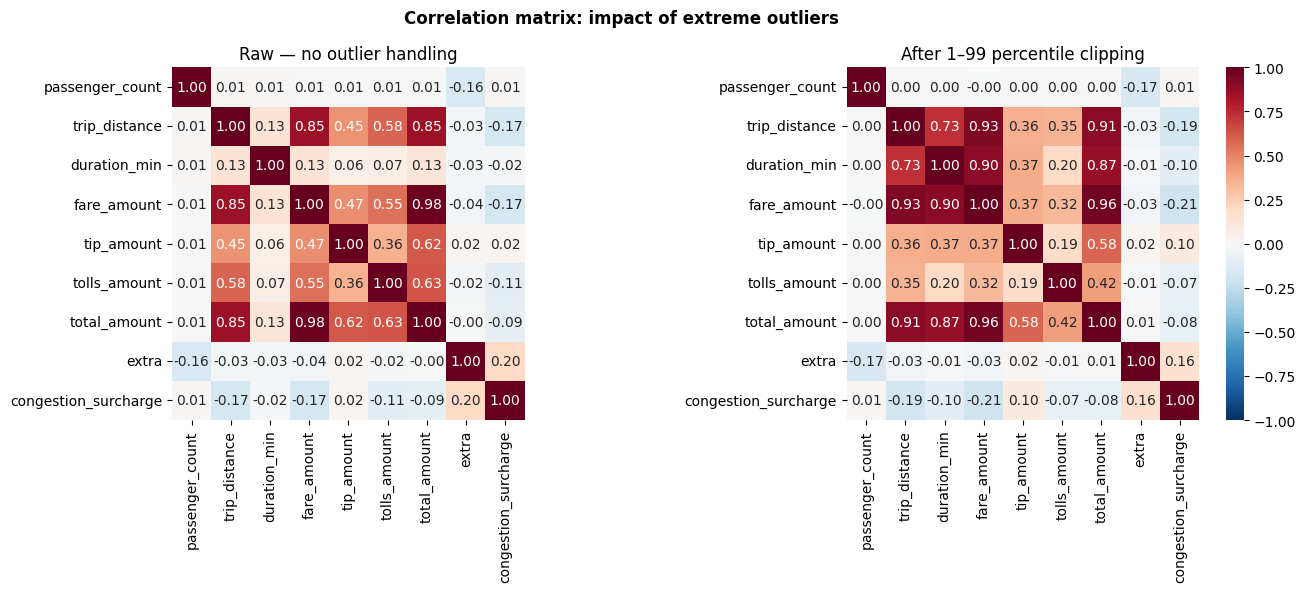

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_cols = ["passenger_count", "trip_distance", "duration_min",
             "fare_amount", "tip_amount", "tolls_amount", "total_amount",
             "extra", "congestion_surcharge"]
# Filter scatter sample at 1-99 percentiles per column
scatter_sample = sample_df[corr_cols + ["payment_type"]].copy()
for c in corr_cols:
    lo, hi = scatter_sample[c].quantile([0.01, 0.99])
    scatter_sample = scatter_sample[(scatter_sample[c] >= lo) & (scatter_sample[c] <= hi)]

raw_corr = sample_df[corr_cols].corr()
sns.heatmap(raw_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0], cbar=False)
axes[0].set_title("Raw — no outlier handling")

clip_corr = scatter_sample[corr_cols].corr()
sns.heatmap(clip_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title("After 1–99 percentile clipping")

fig.suptitle("Correlation matrix: impact of extreme outliers", fontweight="bold")
plt.tight_layout()
plt.show()

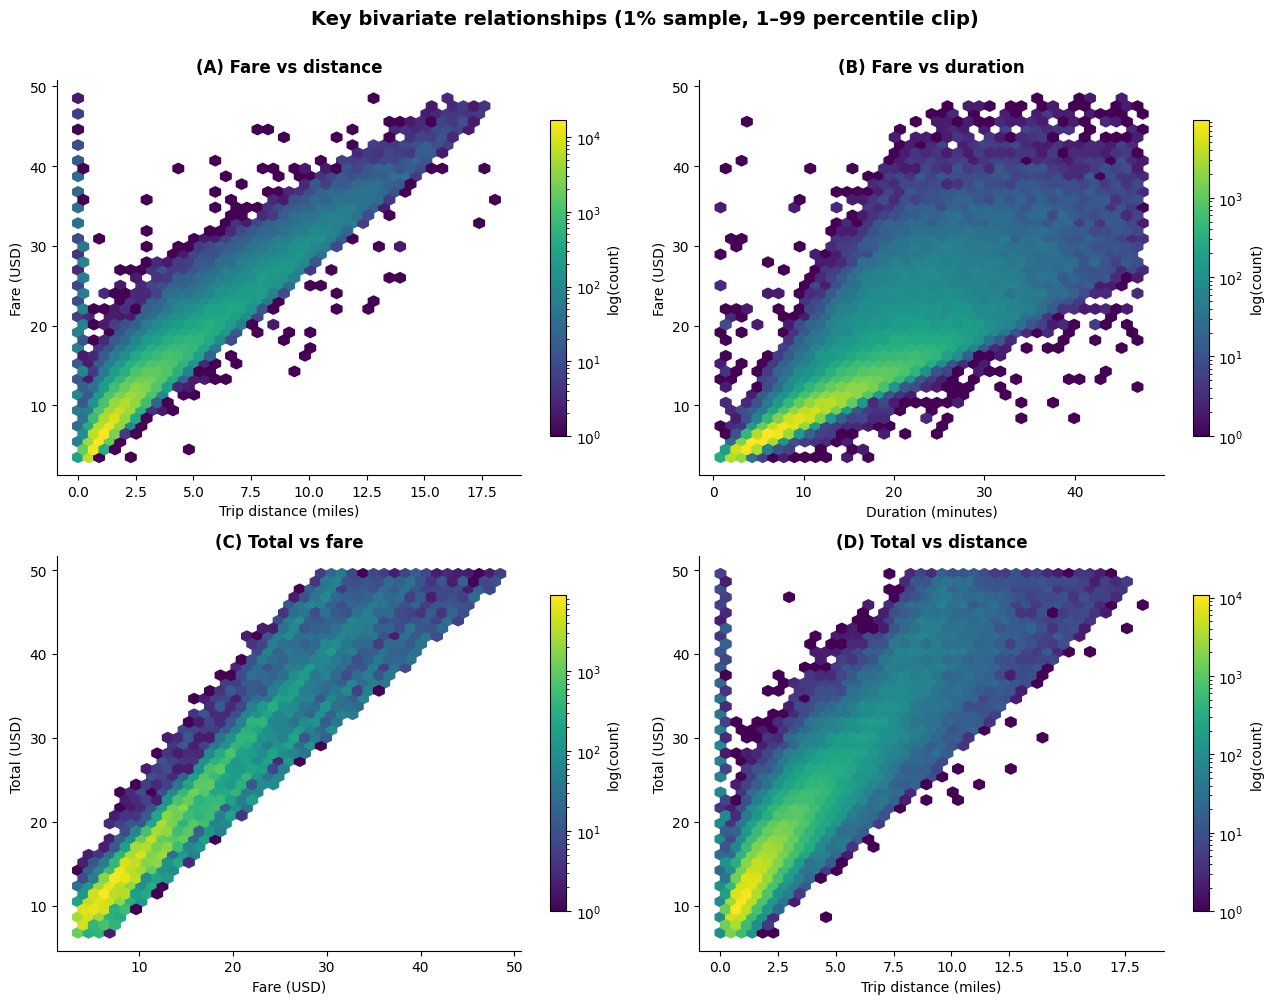

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

def hex_scatter(ax, x, y, xlabel, ylabel, title):
    h = ax.hexbin(scatter_sample[x], scatter_sample[y],
                  gridsize=40, cmap="viridis", mincnt=1, bins="log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    fig.colorbar(h, ax=ax, label="log(count)", shrink=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

hex_scatter(axes[0, 0], "trip_distance", "fare_amount",
            "Trip distance (miles)", "Fare (USD)",
            "(A) Fare vs distance")

hex_scatter(axes[0, 1], "duration_min", "fare_amount",
            "Duration (minutes)", "Fare (USD)",
            "(B) Fare vs duration")

hex_scatter(axes[1, 0], "fare_amount", "total_amount",
            "Fare (USD)", "Total (USD)",
            "(C) Total vs fare")

hex_scatter(axes[1, 1], "trip_distance", "total_amount",
            "Trip distance (miles)", "Total (USD)",
            "(D) Total vs distance")

fig.suptitle("Key bivariate relationships (1% sample, 1–99 percentile clip)",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

#### 3.3.4. Temporal patterns

/var/folders/yp/65klpy9935xg61n4lft7zjrm0000gn/T/ipykernel_9415/1093697523.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


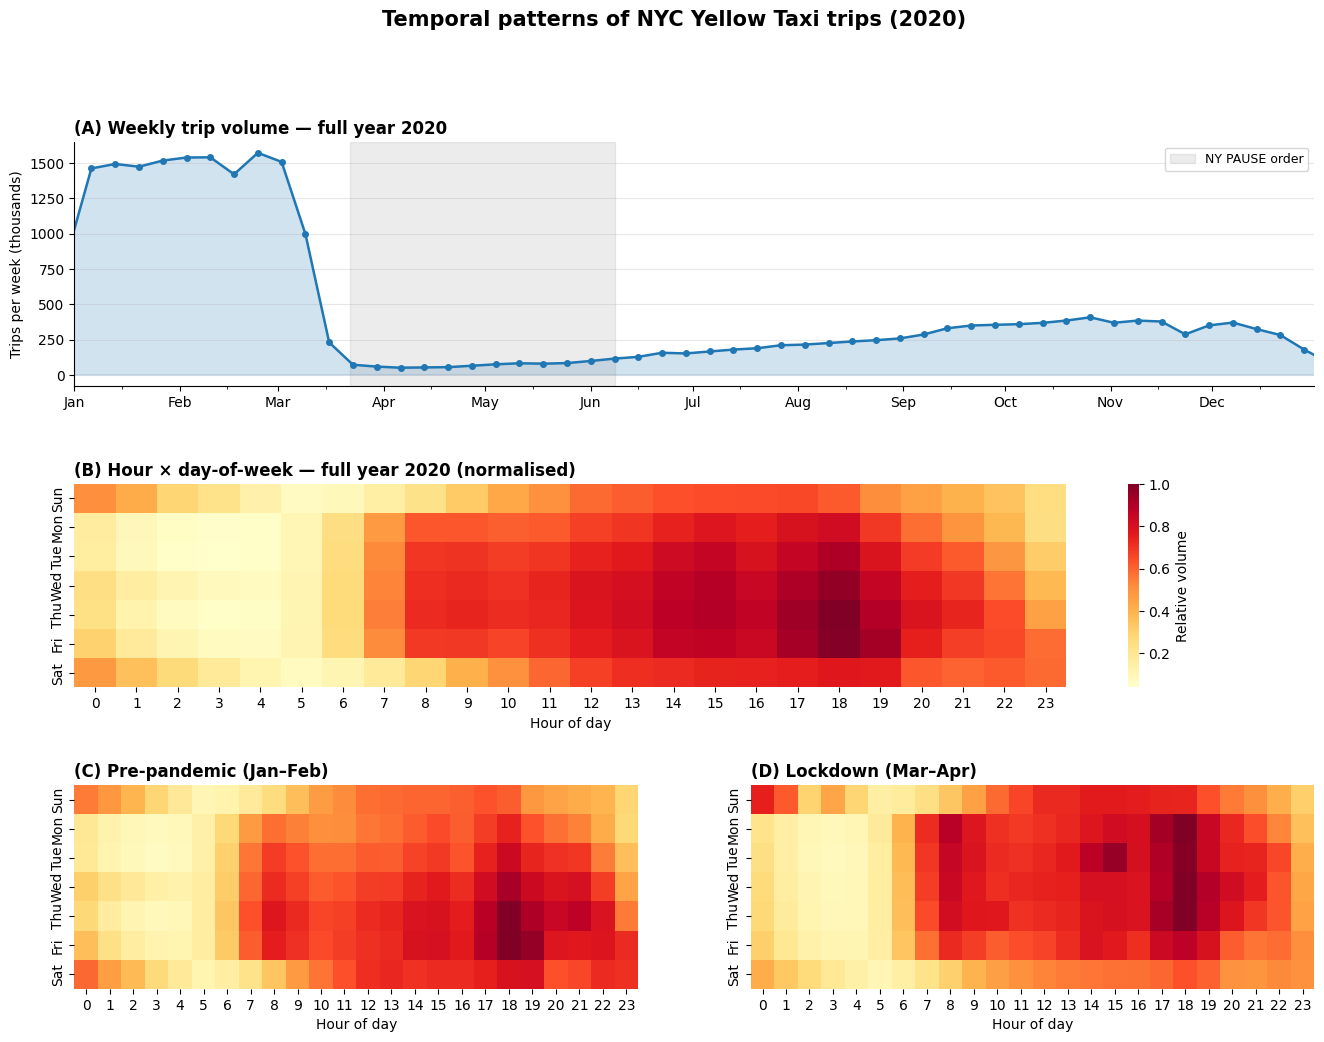

In [17]:
# --- (A) Weekly series ---
weekly = (
    taxi_df_reg
    .filter(month("tpep_pickup_datetime").between(1, 12))
    .withColumn("week_start", date_trunc("week", "tpep_pickup_datetime"))
    .groupBy("week_start").count()
    .orderBy("week_start")
    .toPandas()
)
weekly["week_start"] = pd.to_datetime(weekly["week_start"])

# --- (B,C,D) Hour x DOW heatmaps ---
def hour_dow_pivot(spark_df):
    df = (
        spark_df
        .withColumn("hour", hour("tpep_pickup_datetime"))
        .withColumn("dow",  dayofweek("tpep_pickup_datetime"))   # 1=Sun
        .filter(col("hour").between(0, 23) & col("dow").between(1, 7))
        .groupBy("dow", "hour").count()
        .toPandas()
    )
    pivot = df.pivot(index="dow", columns="hour", values="count").fillna(0)
    pivot.index = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
    return pivot

full_pivot     = hour_dow_pivot(taxi_df_reg)
pre_pivot      = hour_dow_pivot(taxi_df_reg.filter(col("regime") == "1_pre"))
lockdown_pivot = hour_dow_pivot(taxi_df_reg.filter(col("regime") == "2_lockdown"))

# Normalise each pivot to per-week-day-hour rate (otherwise pre has way more data
# than lockdown and the heatmaps aren't comparable)
def normalise(pivot):
    return pivot / pivot.values.max()

# --- Plot ---
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1.2, 1, 1],
                        hspace=0.45, wspace=0.2)

# (A) Weekly series, spans both columns
ax_a = fig.add_subplot(gs[0, :])
ax_a.plot(weekly["week_start"], weekly["count"] / 1e3,
          color="#1f77b4", linewidth=1.8, marker="o", markersize=4)
ax_a.fill_between(weekly["week_start"], weekly["count"] / 1e3,
                  alpha=0.2, color="#1f77b4")
ax_a.set_ylabel("Trips per week (thousands)")
ax_a.set_title("(A) Weekly trip volume — full year 2020",
               fontweight="bold", loc="left")

# Annotate lockdown
lockdown_start = pd.Timestamp("2020-03-22")
lockdown_end   = pd.Timestamp("2020-06-08")
ax_a.axvspan(lockdown_start, lockdown_end, alpha=0.15, color="grey",
             label="NY PAUSE order")
ax_a.legend(loc="upper right", fontsize=9)

# Force monthly ticks on the date axis
ax_a.xaxis.set_major_locator(mdates.MonthLocator())
ax_a.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax_a.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
ax_a.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))

ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.grid(axis="y", alpha=0.3)

# (B) Full year heatmap
ax_b = fig.add_subplot(gs[1, :])
sns.heatmap(normalise(full_pivot), cmap="YlOrRd", ax=ax_b,
            cbar_kws={"label": "Relative volume"})
ax_b.set_title("(B) Hour × day-of-week — full year 2020 (normalised)",
               fontweight="bold", loc="left")
ax_b.set_xlabel("Hour of day")
ax_b.set_ylabel("")

# (C) Pre-pandemic heatmap
ax_c = fig.add_subplot(gs[2, 0])
sns.heatmap(normalise(pre_pivot), cmap="YlOrRd", ax=ax_c, vmin=0, vmax=1,
            cbar=False)
ax_c.set_title("(C) Pre-pandemic (Jan–Feb)", fontweight="bold", loc="left")
ax_c.set_xlabel("Hour of day")
ax_c.set_ylabel("")

# (D) Lockdown heatmap
ax_d = fig.add_subplot(gs[2, 1])
sns.heatmap(normalise(lockdown_pivot), cmap="YlOrRd", ax=ax_d, vmin=0, vmax=1,
            cbar=False)
ax_d.set_title("(D) Lockdown (Mar–Apr)", fontweight="bold", loc="left")
ax_d.set_xlabel("Hour of day")
ax_d.set_ylabel("")

fig.suptitle("Temporal patterns of NYC Yellow Taxi trips (2020)",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

#### 3.3.5. COVID regime dashboard

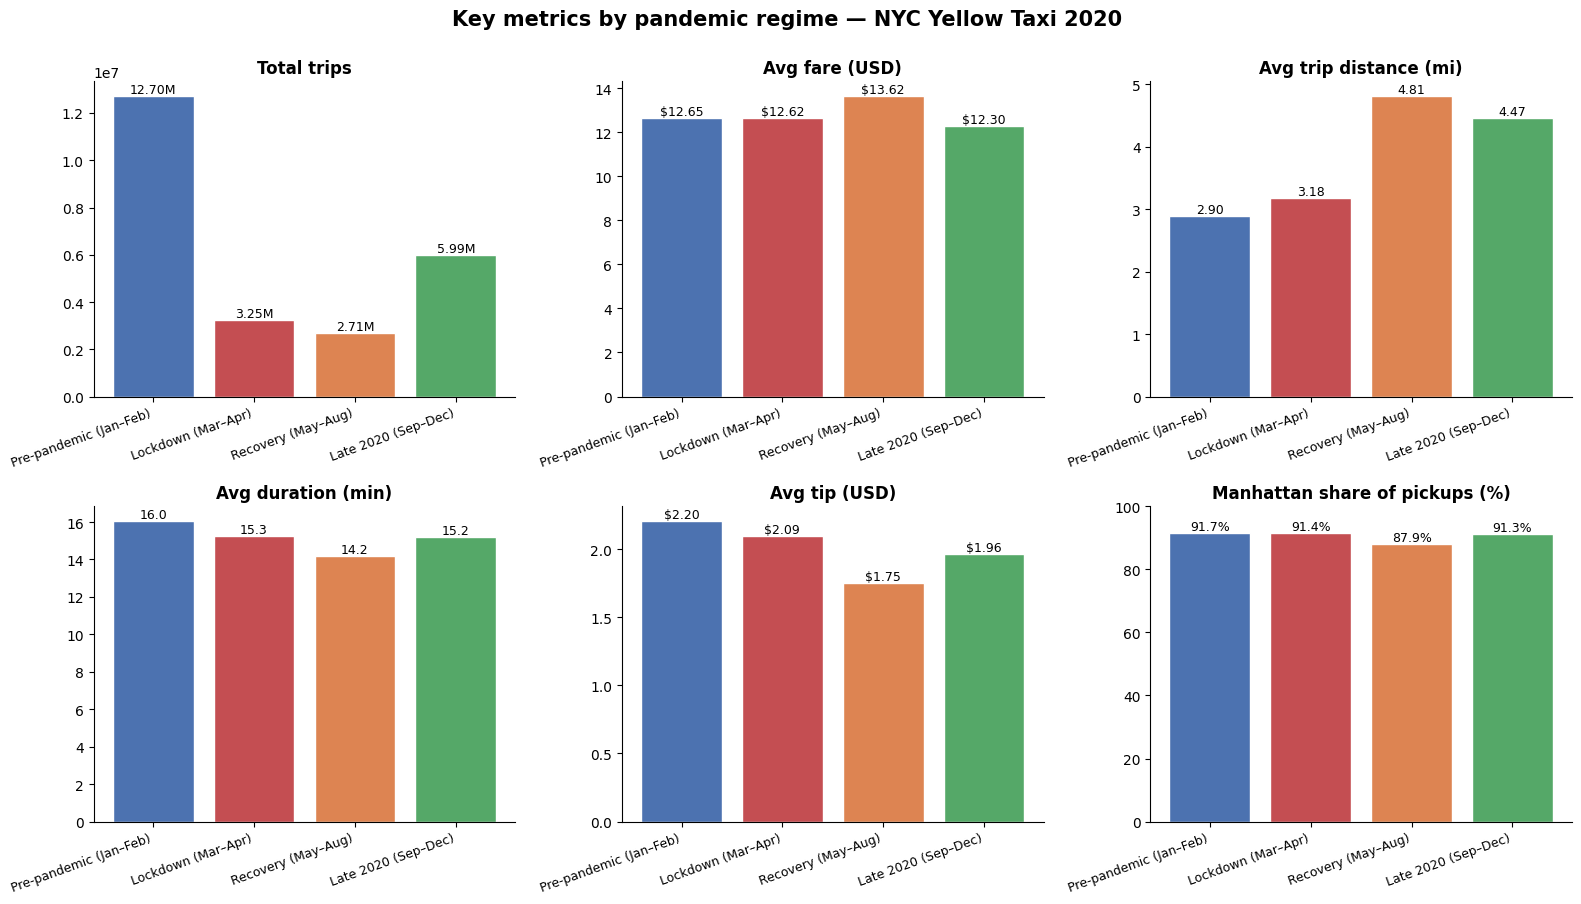

                 label    trips  avg_fare  avg_distance  avg_duration_min  avg_tip
Pre-pandemic (Jan–Feb) 12704691 12.651020      2.897339         16.037993 2.204898
    Lockdown (Mar–Apr)  3245070 12.621831      3.184648         15.267716 2.094019
    Recovery (May–Aug)  2705595 13.621655      4.809487         14.162947 1.753680
   Late 2020 (Sep–Dec)  5993736 12.297599      4.468518         15.185893 1.963306


In [18]:
regime_stats = (
    taxi_df_reg
    .filter(month("tpep_pickup_datetime").between(1, 12))
    .groupBy("regime")
    .agg(
        spark_count("*").alias("trips"),
        avg("trip_distance").alias("avg_distance"),
        avg("fare_amount").alias("avg_fare"),
        avg("tip_amount").alias("avg_tip"),
        avg("total_amount").alias("avg_total"),
        avg(unix_timestamp("tpep_dropoff_datetime") -
            unix_timestamp("tpep_pickup_datetime")).alias("avg_duration_sec"),
    )
    .toPandas()
)
regime_stats["avg_duration_min"] = regime_stats["avg_duration_sec"] / 60
regime_stats = regime_stats.set_index("regime").loc[regime_order].reset_index()
regime_stats["label"] = regime_stats["regime"].map(regime_labels)

# Manhattan share by regime
manh_share = (
    taxi_df_reg
    .filter(month("tpep_pickup_datetime").between(1, 12))
    .groupBy("regime", "PU_Borough").count()
    .toPandas()
)
manh_share_total = manh_share.groupby("regime")["count"].sum()
manh_share_man   = manh_share[manh_share["PU_Borough"] == "Manhattan"] \
                        .set_index("regime")["count"]
manh_pct = (manh_share_man / manh_share_total * 100).reindex(regime_order).reset_index()
manh_pct.columns = ["regime", "manhattan_pct"]
manh_pct["label"] = manh_pct["regime"].map(regime_labels)

# --- Plot: 2x3 dashboard ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = [
    ("trips",            "Total trips",            lambda v: f"{v/1e6:.2f}M"),
    ("avg_fare",         "Avg fare (USD)",         lambda v: f"${v:,.2f}"),
    ("avg_distance",     "Avg trip distance (mi)", lambda v: f"{v:.2f}"),
    ("avg_duration_min", "Avg duration (min)",     lambda v: f"{v:.1f}"),
    ("avg_tip",          "Avg tip (USD)",          lambda v: f"${v:,.2f}"),
]

# Use the regime palette consistently
colors = [regime_palette[r] for r in regime_stats["regime"]]
xpos   = range(len(regime_stats))

for ax, (m, title, fmt) in zip(axes.flat[:5], metrics):
    ax.bar(xpos, regime_stats[m], color=colors, edgecolor="white")
    ax.set_xticks(xpos)
    ax.set_xticklabels(regime_stats["label"], rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for i, v in enumerate(regime_stats[m]):
        ax.text(i, v, fmt(v), ha="center", va="bottom", fontsize=9)

# 6th panel — Manhattan share
ax6 = axes.flat[5]
ax6.bar(range(len(manh_pct)), manh_pct["manhattan_pct"],
        color=[regime_palette[r] for r in manh_pct["regime"]],
        edgecolor="white")
ax6.set_xticks(range(len(manh_pct)))
ax6.set_xticklabels(manh_pct["label"], rotation=20, ha="right", fontsize=9)
ax6.set_title("Manhattan share of pickups (%)", fontweight="bold")
ax6.spines["top"].set_visible(False)
ax6.spines["right"].set_visible(False)
ax6.set_ylim(0, 100)
for i, v in enumerate(manh_pct["manhattan_pct"]):
    ax6.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

fig.suptitle("Key metrics by pandemic regime — NYC Yellow Taxi 2020",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

print(regime_stats[["label", "trips", "avg_fare", "avg_distance",
                    "avg_duration_min", "avg_tip"]].to_string(index=False))

#### 3.3.6. Geographic exploration

In [19]:
SHAPEFILE_PATH = "./data/taxi_zones/taxi_zones.shp"

zones_gdf = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)  # WGS84
zones_gdf["centroid"] = (
    zones_gdf.to_crs(epsg=2263).geometry.centroid.to_crs(epsg=4326)
)
print(f"Loaded {len(zones_gdf)} taxi zone polygons")
print(zones_gdf.columns.tolist())
zones_gdf.head(2)

Loaded 263 taxi zone polygons
['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry', 'centroid']


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,centroid
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,...",POINT (-74.174 40.69183)
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ...",POINT (-73.8313 40.61675)


/var/folders/yp/65klpy9935xg61n4lft7zjrm0000gn/T/ipykernel_9415/3751152977.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


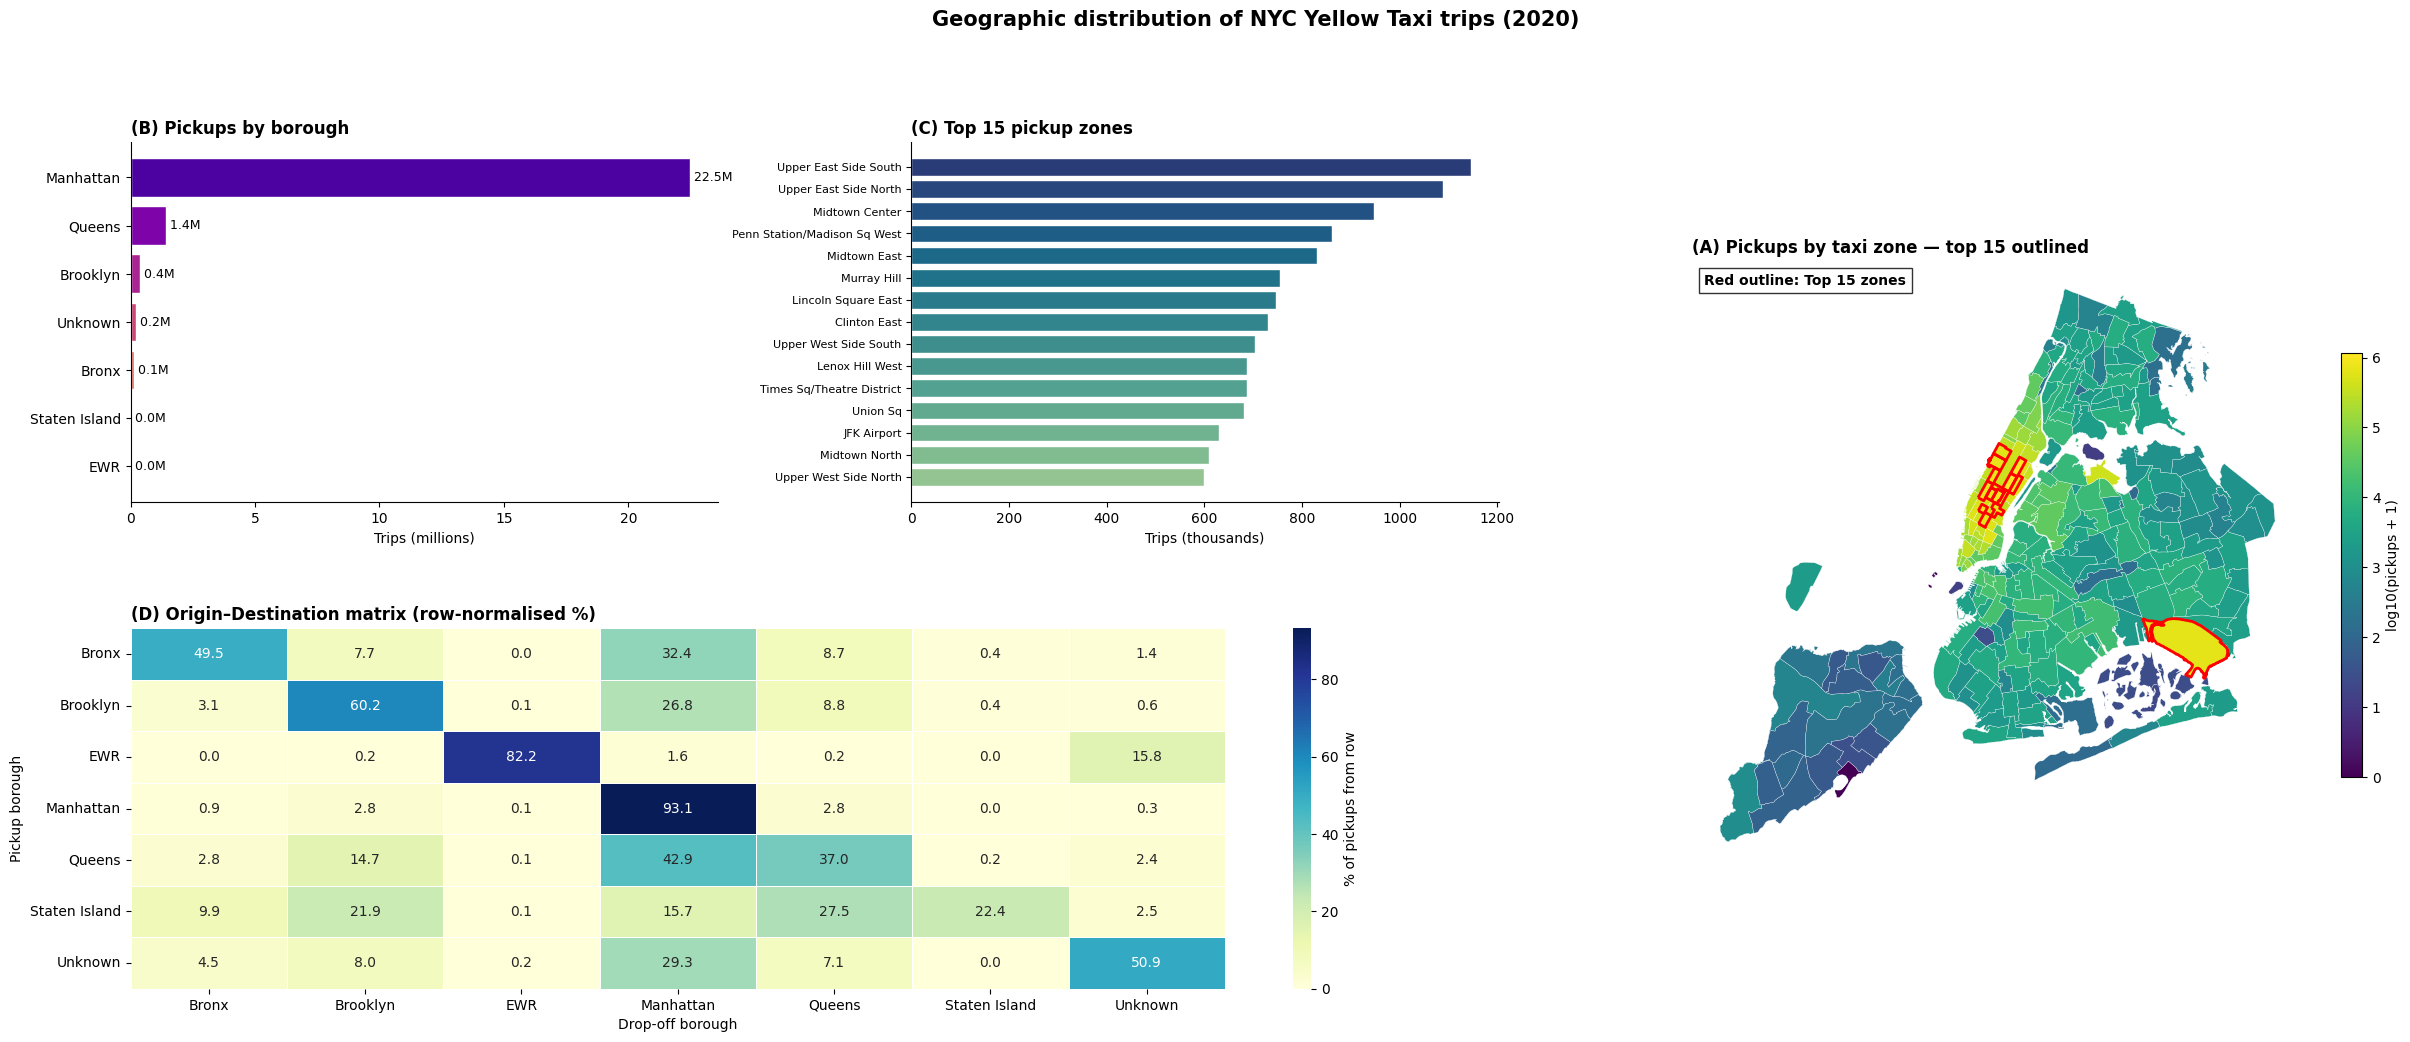

In [20]:
# (1) Borough-level counts
borough_counts = (
    taxi_df_reg
    .filter(month("tpep_pickup_datetime").between(1, 12))
    .groupBy("PU_Borough").count()
    .orderBy(col("count").desc())
    .toPandas()
)

# (2) Top 15 zones (now including LocationID so we can match in the map)
top_zones = (
    taxi_df_reg
    .filter(month("tpep_pickup_datetime").between(1, 12))
    .groupBy("PULocationID", "PU_Zone", "PU_Borough").count()
    .orderBy(col("count").desc()).limit(15)
    .toPandas()
)

# (3) OD heatmap (borough x borough)
od_matrix = (
    taxi_df_reg
    .filter(month("tpep_pickup_datetime").between(1, 12))
    .groupBy("PU_Borough", "DO_Borough").count()
    .toPandas()
)
od_pivot = od_matrix.pivot(index="PU_Borough", columns="DO_Borough",
                           values="count").fillna(0)
od_pct = od_pivot.div(od_pivot.sum(axis=1), axis=0) * 100

# (4) Pickups per zone (for choropleth map)
pu_zone_counts = (
    taxi_df_reg
    .filter(month("tpep_pickup_datetime").between(1, 12))
    .groupBy("PULocationID").count()
    .toPandas()
)
zones_with_data = zones_gdf.merge(
    pu_zone_counts,
    left_on="LocationID", right_on="PULocationID",
    how="left"
).fillna({"count": 0})
zones_with_data["count_log"] = np.log10(zones_with_data["count"] + 1)

# Mark the top 15 zones in the geodataframe
top_zone_ids = set(top_zones["PULocationID"].tolist())
zones_with_data["is_top"] = zones_with_data["LocationID"].isin(top_zone_ids)

# --- Plot ---
fig = plt.figure(figsize=(30, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3,
                        width_ratios=[1, 1, 1.3])

# (A) Choropleth map of pickups, with top-15 zones outlined in black
ax_map = fig.add_subplot(gs[:, 2])
zones_with_data.plot(
    column="count_log", cmap="viridis",
    linewidth=0.2, edgecolor="white",
    ax=ax_map, legend=True,
    legend_kwds={"label": "log10(pickups + 1)", "shrink": 0.5}
)
zones_with_data[zones_with_data["is_top"]].boundary.plot(
    ax=ax_map, color="red", linewidth=2
)
ax_map.text(
    0.02, 0.98, "Red outline: Top 15 zones",
    transform=ax_map.transAxes,
    fontsize=10, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)

ax_map.set_title("(A) Pickups by taxi zone — top 15 outlined",
                 fontweight="bold", loc="left")
ax_map.set_axis_off()

# (B) Borough bar chart
ax_b = fig.add_subplot(gs[0, 0])
ax_b.barh(borough_counts["PU_Borough"], borough_counts["count"] / 1e6,
          color=sns.color_palette("plasma", len(borough_counts)),
          edgecolor="white")
ax_b.set_xlabel("Trips (millions)")
ax_b.set_title("(B) Pickups by borough", fontweight="bold", loc="left")
ax_b.invert_yaxis()
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)
for i, v in enumerate(borough_counts["count"]):
    ax_b.text(v/1e6, i, f" {v/1e6:.1f}M", va="center", fontsize=9)

# (C) Top 15 zones, labels prefixed with their rank number
ax_c = fig.add_subplot(gs[0, 1])
labels = [f"{z}" for i, z in enumerate(top_zones["PU_Zone"])]
ax_c.barh(labels[::-1], top_zones["count"][::-1] / 1e3,
          color=sns.color_palette("crest", 15), edgecolor="white")
ax_c.set_xlabel("Trips (thousands)")
ax_c.set_title("(C) Top 15 pickup zones", fontweight="bold", loc="left")
ax_c.spines["top"].set_visible(False)
ax_c.spines["right"].set_visible(False)
ax_c.tick_params(axis="y", labelsize=8)

# (D) Borough-to-borough OD heatmap
ax_d = fig.add_subplot(gs[1, 0:2])
sns.heatmap(od_pct, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={"label": "% of pickups from row"},
            ax=ax_d, linewidths=0.5)
ax_d.set_title("(D) Origin–Destination matrix (row-normalised %)",
               fontweight="bold", loc="left")
ax_d.set_xlabel("Drop-off borough")
ax_d.set_ylabel("Pickup borough")

fig.suptitle("Geographic distribution of NYC Yellow Taxi trips (2020)",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

#### 3.3.7. Payment method shift during pandemic

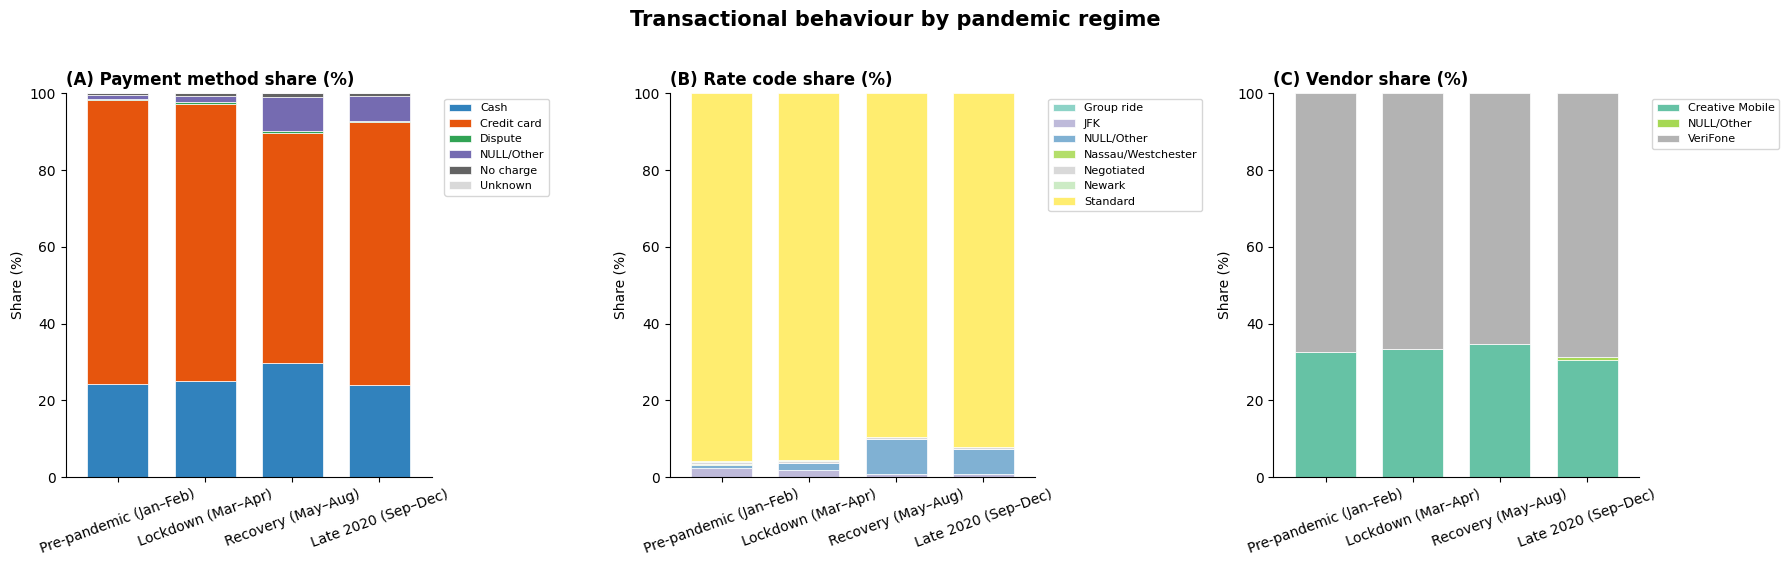

Payment method (%):
payment_type            Cash  Credit card  Dispute  NULL/Other  No charge  Unknown
Pre-pandemic (Jan–Feb)  24.3         74.0      0.3         0.9        0.5      0.0
Lockdown (Mar–Apr)      25.1         72.2      0.3         1.8        0.6      0.0
Recovery (May–Aug)      29.6         60.1      0.4         9.0        0.9      0.0
Late 2020 (Sep–Dec)     24.1         68.3      0.4         6.6        0.6      0.0


In [21]:
pay_map = {1: "Credit card", 2: "Cash", 3: "No charge", 4: "Dispute",
           5: "Unknown", 6: "Voided"}
rate_map = {1: "Standard", 2: "JFK", 3: "Newark",
            4: "Nassau/Westchester", 5: "Negotiated", 6: "Group ride"}
vendor_map = {1: "Creative Mobile", 2: "VeriFone"}

def share_by_regime(spark_df, col_name, label_map):
    out = spark_df.groupBy("regime", col_name).count().toPandas()
    out[col_name] = out[col_name].map(label_map).fillna("NULL/Other")
    pivot = out.pivot_table(index="regime", columns=col_name,
                            values="count", aggfunc="sum", fill_value=0)
    pivot = pivot.reindex(regime_order)
    pivot.index = [regime_labels[r] for r in pivot.index]
    return pivot.div(pivot.sum(axis=1), axis=0) * 100

pay_pct    = share_by_regime(taxi_df_reg, "payment_type", pay_map)
rate_pct   = share_by_regime(taxi_df_reg, "RatecodeID",   rate_map)
vendor_pct = share_by_regime(taxi_df_reg, "VendorID",     vendor_map)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

palettes = ["tab20c", "Set3", "Set2"]
data_titles = [
    (pay_pct,    "(A) Payment method share (%)"),
    (rate_pct,   "(B) Rate code share (%)"),
    (vendor_pct, "(C) Vendor share (%)"),
]

for ax, (data, title), pal in zip(axes, data_titles, palettes):
    data.plot(kind="bar", stacked=True, ax=ax, colormap=pal,
              edgecolor="white", linewidth=0.5, width=0.7)
    ax.set_title(title, fontweight="bold", loc="left")
    ax.set_ylabel("Share (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Transactional behaviour by pandemic regime",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Payment method (%):")
print(pay_pct.round(1).to_string())

### 3.4. Verify Data Quality

#### 3.4.1. Missing values

In [22]:


# ---------- 3.4.1 Missing values (corrected) ----------
n_rows = taxi_df.count()
print(f"Total rows: {n_rows:,}")

# Build expressions explicitly: (null_count * 100.0) / n_rows
missing_exprs = [
    (count(when(col(c).isNull(), c)) * lit(100.0) / lit(n_rows)).alias(c)
    for c in taxi_df.columns
]
missing = taxi_df.select(missing_exprs).toPandas().T
missing.columns = ["missing_pct"]
missing = missing.sort_values("missing_pct", ascending=False)

# Sanity check
assert missing["missing_pct"].max() <= 100.0, "Bug still present!"
assert missing["missing_pct"].min() >= 0.0

print(missing)

Total rows: 24,649,092


                       missing_pct
airport_fee              99.999915
passenger_count           3.285991
RatecodeID                3.285991
store_and_fwd_flag        3.285991
congestion_surcharge      3.285991
DOLocationID              0.000000
tolls_amount              0.000000
DO_Zone                   0.000000
DO_Borough                0.000000
PU_service_zone           0.000000
PU_Zone                   0.000000
PU_Borough                0.000000
total_amount              0.000000
improvement_surcharge     0.000000
mta_tax                   0.000000
tip_amount                0.000000
PULocationID              0.000000
extra                     0.000000
fare_amount               0.000000
payment_type              0.000000
trip_distance             0.000000
tpep_dropoff_datetime     0.000000
tpep_pickup_datetime      0.000000
VendorID                  0.000000
DO_service_zone           0.000000


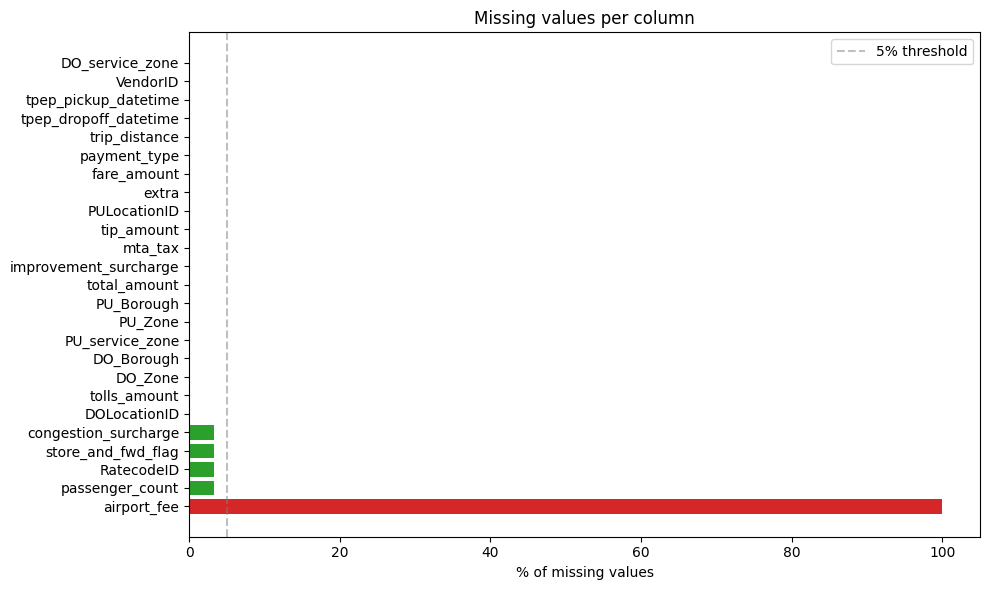

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d62728" if v > 50 else "#ff7f0e" if v > 5 else "#2ca02c"
          for v in missing["missing_pct"]]
ax.barh(missing.index, missing["missing_pct"], color=colors)
ax.set_xlabel("% of missing values")
ax.set_title("Missing values per column")
ax.axvline(5, ls="--", color="grey", alpha=0.5, label="5% threshold")
ax.legend()
plt.tight_layout()
plt.show()

#### 3.4.2. Duplicates

In [24]:
n_distinct = taxi_df.distinct().count()
n_dup = n_rows - n_distinct
print(f"Total rows       : {n_rows:,}")
print(f"Distinct rows    : {n_distinct:,}")
print(f"Duplicate rows   : {n_dup:,} ({100*n_dup/n_rows:.4f}%)")

Total rows       : 24,649,092
Distinct rows    : 24,636,142
Duplicate rows   : 12,950 (0.0525%)


#### 3.4.3. Out-of-range timestamps

In [25]:
oor = (
    taxi_df
    .filter((year("tpep_pickup_datetime") != 2020) |
            (year("tpep_dropoff_datetime") != 2020))
    .groupBy(year("tpep_pickup_datetime").alias("pickup_year"))
    .count()
    .orderBy("pickup_year")
    .toPandas()
)
print("Trips with pickup year ≠ 2020:")
print(oor.to_string(index=False))
print(f"\nTotal out-of-range: {oor['count'].sum():,} "
      f"({100*oor['count'].sum()/n_rows:.4f}%)")

Trips with pickup year ≠ 2020:
 pickup_year  count
        2002      1
        2003      2
        2008     32
        2009     90
        2019    131
        2020    183
        2021     24

Total out-of-range: 463 (0.0019%)


#### 3.4.4. Impossible/outlier values

In [26]:
checks = {
    "trip_distance <= 0":           taxi_df.filter(col("trip_distance") <= 0).count(),
    "trip_distance > 100 miles":    taxi_df.filter(col("trip_distance") > 100).count(),
    "fare_amount < 0":              taxi_df.filter(col("fare_amount") < 0).count(),
    "fare_amount > 500":            taxi_df.filter(col("fare_amount") > 500).count(),
    "total_amount < 0":             taxi_df.filter(col("total_amount") < 0).count(),
    "total_amount > 1000":          taxi_df.filter(col("total_amount") > 1000).count(),
    "tip_amount < 0":               taxi_df.filter(col("tip_amount") < 0).count(),
    "passenger_count = 0":          taxi_df.filter(col("passenger_count") == 0).count(),
    "passenger_count > 6":          taxi_df.filter(col("passenger_count") > 6).count(),
    "dropoff < pickup":             taxi_df.filter(col("tpep_dropoff_datetime") < col("tpep_pickup_datetime")).count(),
    "duration > 6h":                taxi_df.filter(
        (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) > 6*3600
    ).count(),
    "duration < 1 min":             taxi_df.filter(
        (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) < 60
    ).count(),
}

quality_df = pd.DataFrame(list(checks.items()), columns=["Issue", "Count"])
quality_df["% of total"] = 100 * quality_df["Count"] / n_rows
quality_df = quality_df.sort_values("Count", ascending=False).reset_index(drop=True)
print(quality_df.to_string(index=False))

                    Issue  Count  % of total
      passenger_count = 0 489385    1.985408
       trip_distance <= 0 332448    1.348723
         duration < 1 min 290212    1.177374
          fare_amount < 0  92833    0.376618
         total_amount < 0  92683    0.376010
            duration > 6h  48037    0.194883
         dropoff < pickup  20011    0.081184
           tip_amount < 0   1013    0.004110
trip_distance > 100 miles    379    0.001538
      passenger_count > 6    200    0.000811
        fare_amount > 500    116    0.000471
      total_amount > 1000     26    0.000105


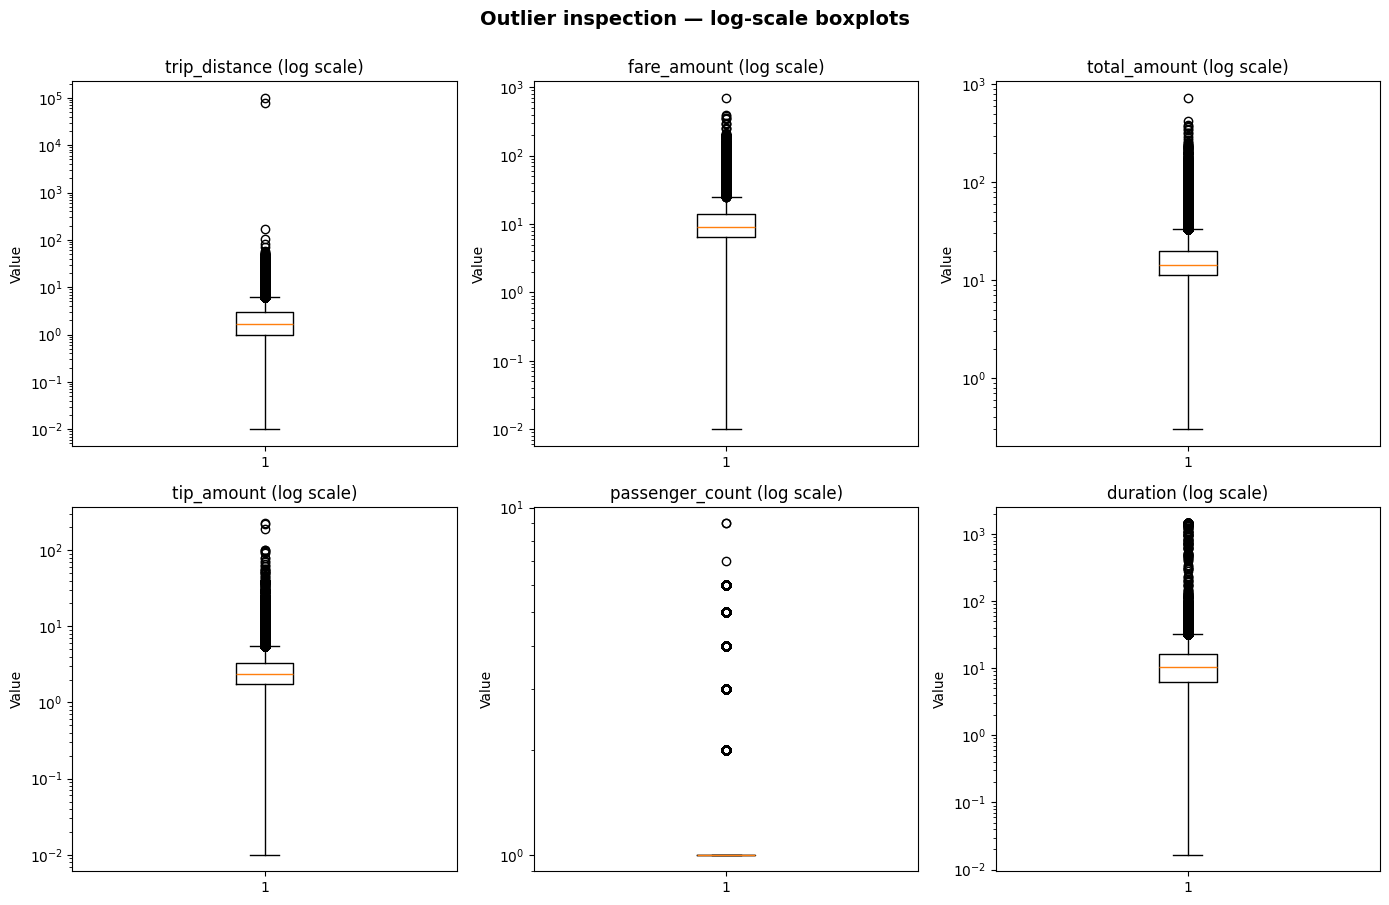

In [27]:
out_sample = taxi_df.select(
    "trip_distance", "fare_amount", "total_amount", "tip_amount", "passenger_count",
    ((unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60).alias("duration")
).sample(0.01, seed=42).toPandas()

cols_to_plot = ["trip_distance", "fare_amount", "total_amount",
                "tip_amount", "passenger_count", "duration"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()   # <-- transforma o 2x3 array num array 1D de 6 axes

for ax, c in zip(axes, cols_to_plot):
    data = out_sample[c].dropna()
    data = data[data > 0]   # drop non-positive for log scale
    ax.boxplot(data, vert=True, showfliers=True)
    ax.set_yscale("log")
    ax.set_title(f"{c} (log scale)")
    ax.set_ylabel("Value")

fig.suptitle("Outlier inspection — log-scale boxplots", y=1.00, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3.4.5. Consistency check: airport_fee

In [28]:
print("airport_fee — non-null records in 2020:")
taxi_df.filter(col("airport_fee").isNotNull()).count()

airport_fee — non-null records in 2020:


21

#### 3.4.6. Summary of data-quality findings

| Issue | Severity | Strategy |
|---|---|---|
| `airport_fee` 100% null in 2020 | High | **Drop column** |
| Out-of-range pickup years (`2008`, `2030`, …) | Low (<0.01%) | **Filter** |
| `passenger_count` null / 0 / >6 | Medium | **Filter** to `[1, 6]` |
| `trip_distance <= 0` | Medium | **Filter** to `> 0` |
| `fare_amount`, `total_amount` negative | Medium | **Filter** to `>= 0` |
| `total_amount` > $1000 | Low | **Filter** (likely meter errors) |
| Duration `< 1 min` or `> 6 h` | Medium | **Filter** |
| `dropoff < pickup` | Low | **Filter** |
| Duplicate rows | Very low | **Drop** |
| `RatecodeID`, `congestion_surcharge` missing | Low | Tolerate (rare) |

This cleaning pipeline is applied in **Section 4** before the analytical queries and the ML pipeline.

---

## **4. Queries**

### **4.0. Cleaning pipeline**

Before running the queries a minimal cleaning step is applied to remove records that would distort geographic aggregates: pickups/dropoffs outside 2020, non-positive `total_amount` (refunds and disputes) and invalid `LocationID` values (the official TLC zone catalogue covers IDs 1–263).

In [29]:
taxi_clean = (
    taxi_df
    # Time range
    .filter((year("tpep_pickup_datetime")  == 2020) &
            (year("tpep_dropoff_datetime") == 2020))
    # Valid taxi-zone codes (TLC catalogue: 1..263)
    .filter(col("PULocationID").between(1, 263) &
            col("DOLocationID").between(1, 263))
    # Drop refunds/disputes for revenue-based queries
    .filter(col("total_amount") > 0)
)

# Register SQL view (needed for the Spark SQL versions)
taxi_clean.createOrReplaceTempView("taxi")

# Cache: every query below scans this dataframe
taxi_clean.cache()
clean_count = taxi_clean.count()

print(f"Original rows: {n_rows:,}")
print(f"Clean rows:    {clean_count:,}")
print(f"Removed:       {n_rows - clean_count:,} "
      f"({100*(n_rows - clean_count)/n_rows:.2f}%)")

Original rows: 24,649,092
Clean rows:    24,233,516
Removed:       415,576 (1.69%)


### **4.1. Billing and Tips**

...

### **4.2. Geographic Patterns**

#### 4.2.1. Query 1 — Top 10 pickup locations

> *Which are the 10 most frequent pickup zones in 2020?*

The simplest geographic aggregate. We rank the 263 taxi zones by their pickup count and inspect the leading 10. This is also a sanity check: the result should align with our prior expectation that activity concentrates in Manhattan and the airports.

In [30]:
# Spark DataFrame API
q1_df = (
    taxi_clean
    .groupBy("PULocationID", "PU_Zone", "PU_Borough")
    .agg(spark_count("*").alias("pickups"))
    .orderBy(col("pickups").desc())
    .limit(10)
)
q1_pd = q1_df.toPandas()
q1_pd

,PULocationID,PU_Zone,PU_Borough,pickups
0,237,Upper East Side South,Manhattan,1139886
1,236,Upper East Side North,Manhattan,1084899
2,161,Midtown Center,Manhattan,941414
3,186,Penn Station/Madison Sq West,Manhattan,856161
4,162,Midtown East,Manhattan,827150
5,170,Murray Hill,Manhattan,750326
6,142,Lincoln Square East,Manhattan,743805
7,48,Clinton East,Manhattan,723750
8,239,Upper West Side South,Manhattan,700620
9,141,Lenox Hill West,Manhattan,684513


In [31]:
# Spark SQL
q1_sql = spark.sql("""
    SELECT
        PULocationID,
        PU_Zone,
        PU_Borough,
        COUNT(*) AS pickups
    FROM taxi
    GROUP BY PULocationID, PU_Zone, PU_Borough
    ORDER BY pickups DESC
    LIMIT 10
""")
q1_sql_pd = q1_sql.toPandas()

# Sanity check — both versions must agree
assert q1_pd.equals(q1_sql_pd), "DataFrame and SQL results differ!"
print("✔ DataFrame API and SQL produce identical results")
q1_sql_pd

✔ DataFrame API and SQL produce identical results


,PULocationID,PU_Zone,PU_Borough,pickups
0,237,Upper East Side South,Manhattan,1139886
1,236,Upper East Side North,Manhattan,1084899
2,161,Midtown Center,Manhattan,941414
3,186,Penn Station/Madison Sq West,Manhattan,856161
4,162,Midtown East,Manhattan,827150
5,170,Murray Hill,Manhattan,750326
6,142,Lincoln Square East,Manhattan,743805
7,48,Clinton East,Manhattan,723750
8,239,Upper West Side South,Manhattan,700620
9,141,Lenox Hill West,Manhattan,684513


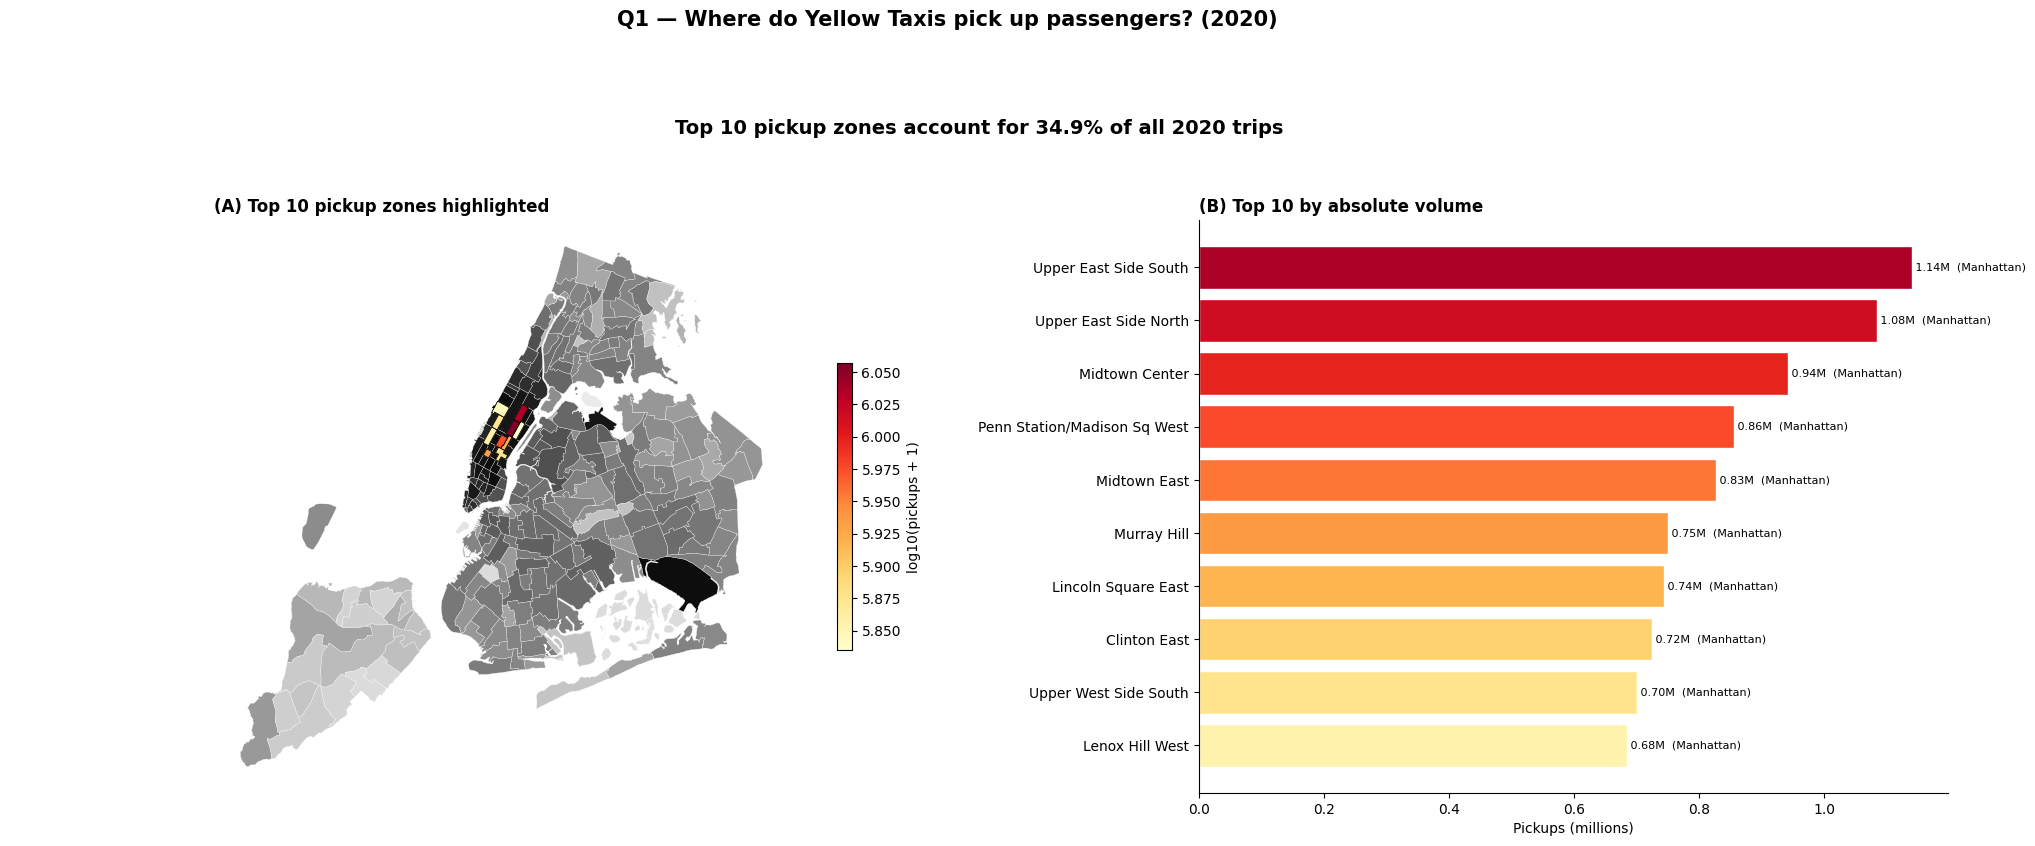

In [32]:
# Visualisation
# (A) Pickup map with top-10 highlighted
# (B) Horizontal bar chart with the same top-10
# (C) "Share of total" header showing how concentrated the top-10 is

# Prepare the geo data
top10_ids = set(q1_pd["PULocationID"].tolist())
all_pu = (
    taxi_clean.groupBy("PULocationID").count()
    .toPandas()
    .rename(columns={"count": "pickups"})
)
zones_q1 = zones_gdf.merge(all_pu, left_on="LocationID",
                           right_on="PULocationID", how="left").fillna({"pickups": 0})
zones_q1["is_top10"] = zones_q1["LocationID"].isin(top10_ids)
zones_q1["pickups_log"] = np.log10(zones_q1["pickups"] + 1)

# Share of total
top10_share = q1_pd["pickups"].sum() / clean_count * 100

# --- Plot ---
fig = plt.figure(figsize=(25, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        width_ratios=[1.3, 1], height_ratios=[0.1, 1],
                        hspace=0.2, wspace=0.25)

# Header
ax_head = fig.add_subplot(gs[0, :])
ax_head.axis("off")
ax_head.text(
    0.5, 0.5,
    f"Top 10 pickup zones account for "
    f"{top10_share:.1f}% of all 2020 trips",
    ha="center", va="center", fontsize=14, fontweight="bold",
    transform=ax_head.transAxes
)

# (A) Map
ax_map = fig.add_subplot(gs[1, 0])
zones_q1.plot(column="pickups_log", cmap="Greys", linewidth=0.2,
              edgecolor="white", ax=ax_map)
zones_q1[zones_q1["is_top10"]].plot(
    column="pickups_log", cmap="YlOrRd",
    linewidth=0.6, edgecolor="black", ax=ax_map,
    legend=True, legend_kwds={"label": "log10(pickups + 1)", "shrink": 0.5}
)
ax_map.set_title("(A) Top 10 pickup zones highlighted",
                 fontweight="bold", loc="left")
ax_map.set_axis_off()

# (B) Bar chart
ax_bar = fig.add_subplot(gs[1, 1])
labels = [f"{z}" for i, z in enumerate(q1_pd["PU_Zone"])]
colors = sns.color_palette("YlOrRd_r", len(q1_pd))
bars = ax_bar.barh(labels[::-1], q1_pd["pickups"][::-1] / 1e6,
                   color=colors[::-1], edgecolor="white")
ax_bar.set_xlabel("Pickups (millions)")
ax_bar.set_title("(B) Top 10 by absolute volume",
                 fontweight="bold", loc="left")
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
for bar, v, b in zip(bars, q1_pd["pickups"][::-1], q1_pd["PU_Borough"][::-1]):
    ax_bar.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f" {v/1e6:.2f}M  ({b})", va="center", fontsize=8)

fig.suptitle("Q1 — Where do Yellow Taxis pick up passengers? (2020)",
             fontsize=15, fontweight="bold", y=0.98)
plt.show()

**Analysis**

The result confirms an exceptional **geographic concentration** of yellow-taxi demand. The 10 leading zones — out of 263 in the TLC catalogue — account for **34.9% of all 2020 pickups**, meaning that under 4% of zones generate more than a third of total demand.

Three observations stand out:

1. **All ten zones are in Manhattan.** No zone from Brooklyn, Queens, the Bronx, Staten Island, or even the two airports appears in the top 10. The yellow-taxi business in 2020 was overwhelmingly a *Manhattan operation*, in line with the historical role of yellow cabs (which, by TLC regulation, are the only taxis allowed to take street hails throughout the city, but in practice operate almost exclusively in the Manhattan core).

2. **The leading zones cluster on the East Side and Midtown.** The top two are **Upper East Side South (1.14M trips)** and **Upper East Side North (1.08M)**, followed by **Midtown Center, Penn Station/Madison Sq West and Midtown East**. Together, these five contiguous zones form a dense corridor along the East Side and through Midtown — exactly the area with the highest concentration of office space, hotels, and high-income residential housing in NYC.

3. **The distribution is smooth, not winner-take-all.** The gap between #1 (Upper East Side South, 1.14M) and #10 (Lenox Hill West, 0.68M) is less than a factor of 2. There is no single dominant pickup zone; rather, the top 10 form a fairly homogeneous cluster of *high-demand zones*, all between roughly 0.7M and 1.1M annual pickups.

The **absence of airport zones** from the top 10 is itself a notable finding — JFK and LaGuardia normally rank among the busiest pickup zones, and their absence here reflects the collapse of air travel during 2020. As we will see in Q3, however, airports remain disproportionately important in *revenue* terms even when their *volume* drops, because per-trip fares are much higher. This motivates Q2 (where same-zone trips are examined) and Q3 (where the same geography is revisited from a revenue perspective).

#### 4.2.2. Query 2 — Same-zone trips

> *How often does a trip start and end in the same taxi zone?*

A trip with `PULocationID = DOLocationID` is one of three things: 
1. a legitimate short trip within a dense zone (e.g., somebody crossing Midtown to a meeting), 
2. a metered loop within a large zone like an airport, or 
3. a meter error / cancelled ride.

The visualisation separates these by overlaying the distribution of `trip_distance` for same-zone vs different-zone trips: legitimate same-zone trips should be short; if there is a long tail of multi-mile "same-zone" trips, those are likely data quality issues.

In [33]:
# Spark DataFrame API 
total_clean = clean_count
same_zone_total = taxi_clean.filter(col("PULocationID") == col("DOLocationID")).count()

# Per-zone breakdown (for the map)
q2_df = (
    taxi_clean
    .withColumn("is_same_zone",
                when(col("PULocationID") == col("DOLocationID"), 1).otherwise(0))
    .groupBy("PULocationID", "PU_Zone", "PU_Borough")
    .agg(
        spark_count("*").alias("total_pickups"),
        _sum("is_same_zone").alias("same_zone_trips"),
    )
    .withColumn("pct_same_zone",
                col("same_zone_trips") / col("total_pickups") * 100)
    .filter(col("total_pickups") >= 1000)        # avoid noisy small zones
    .orderBy(col("pct_same_zone").desc())
)
q2_pd = q2_df.toPandas()

print(f"Total trips:          {total_clean:,}")
print(f"Same-zone trips:      {same_zone_total:,} "
      f"({100*same_zone_total/total_clean:.2f}%)")
print(f"\nTop 5 zones by % same-zone:")
print(q2_pd.head(5).to_string(index=False))

Total trips:          24,233,516
Same-zone trips:      1,391,892 (5.74%)

Top 5 zones by % same-zone:
 PULocationID                          PU_Zone PU_Borough  total_pickups  same_zone_trips  pct_same_zone
            1                   Newark Airport        EWR           1765             1723      97.620397
          207 Saint Michaels Cemetery/Woodside     Queens           1764             1285      72.845805
          145   Long Island City/Hunters Point     Queens          30778            15489      50.324907
          193          Queensbridge/Ravenswood     Queens          19546             9391      48.045636
            7                          Astoria     Queens          34175             7619      22.294075


In [34]:
# Spark SQL
q2_sql = spark.sql("""
    SELECT
        PULocationID,
        PU_Zone,
        PU_Borough,
        COUNT(*) AS total_pickups,
        SUM(CASE WHEN PULocationID = DOLocationID THEN 1 ELSE 0 END) AS same_zone_trips,
        (SUM(CASE WHEN PULocationID = DOLocationID THEN 1 ELSE 0 END) * 100.0
         / COUNT(*)) AS pct_same_zone
    FROM taxi
    GROUP BY PULocationID, PU_Zone, PU_Borough
    HAVING COUNT(*) >= 1000
    ORDER BY pct_same_zone DESC
""")
q2_sql_pd = q2_sql.toPandas()

# Sanity check
assert len(q2_pd) == len(q2_sql_pd), "Row counts differ!"
print("✔ Same shape from both implementations")

# Also compute the distance distribution for the violin/density plot
dist_sample = (
    taxi_clean
    .withColumn("is_same_zone",
                when(col("PULocationID") == col("DOLocationID"),
                     "Same zone").otherwise("Different zone"))
    .select("is_same_zone", "trip_distance")
    .sample(0.05, seed=42)
    .toPandas()
)
# Clip extremes for visualisation
dist_sample = dist_sample[(dist_sample["trip_distance"] > 0) &
                          (dist_sample["trip_distance"] < 20)]

✔ Same shape from both implementations


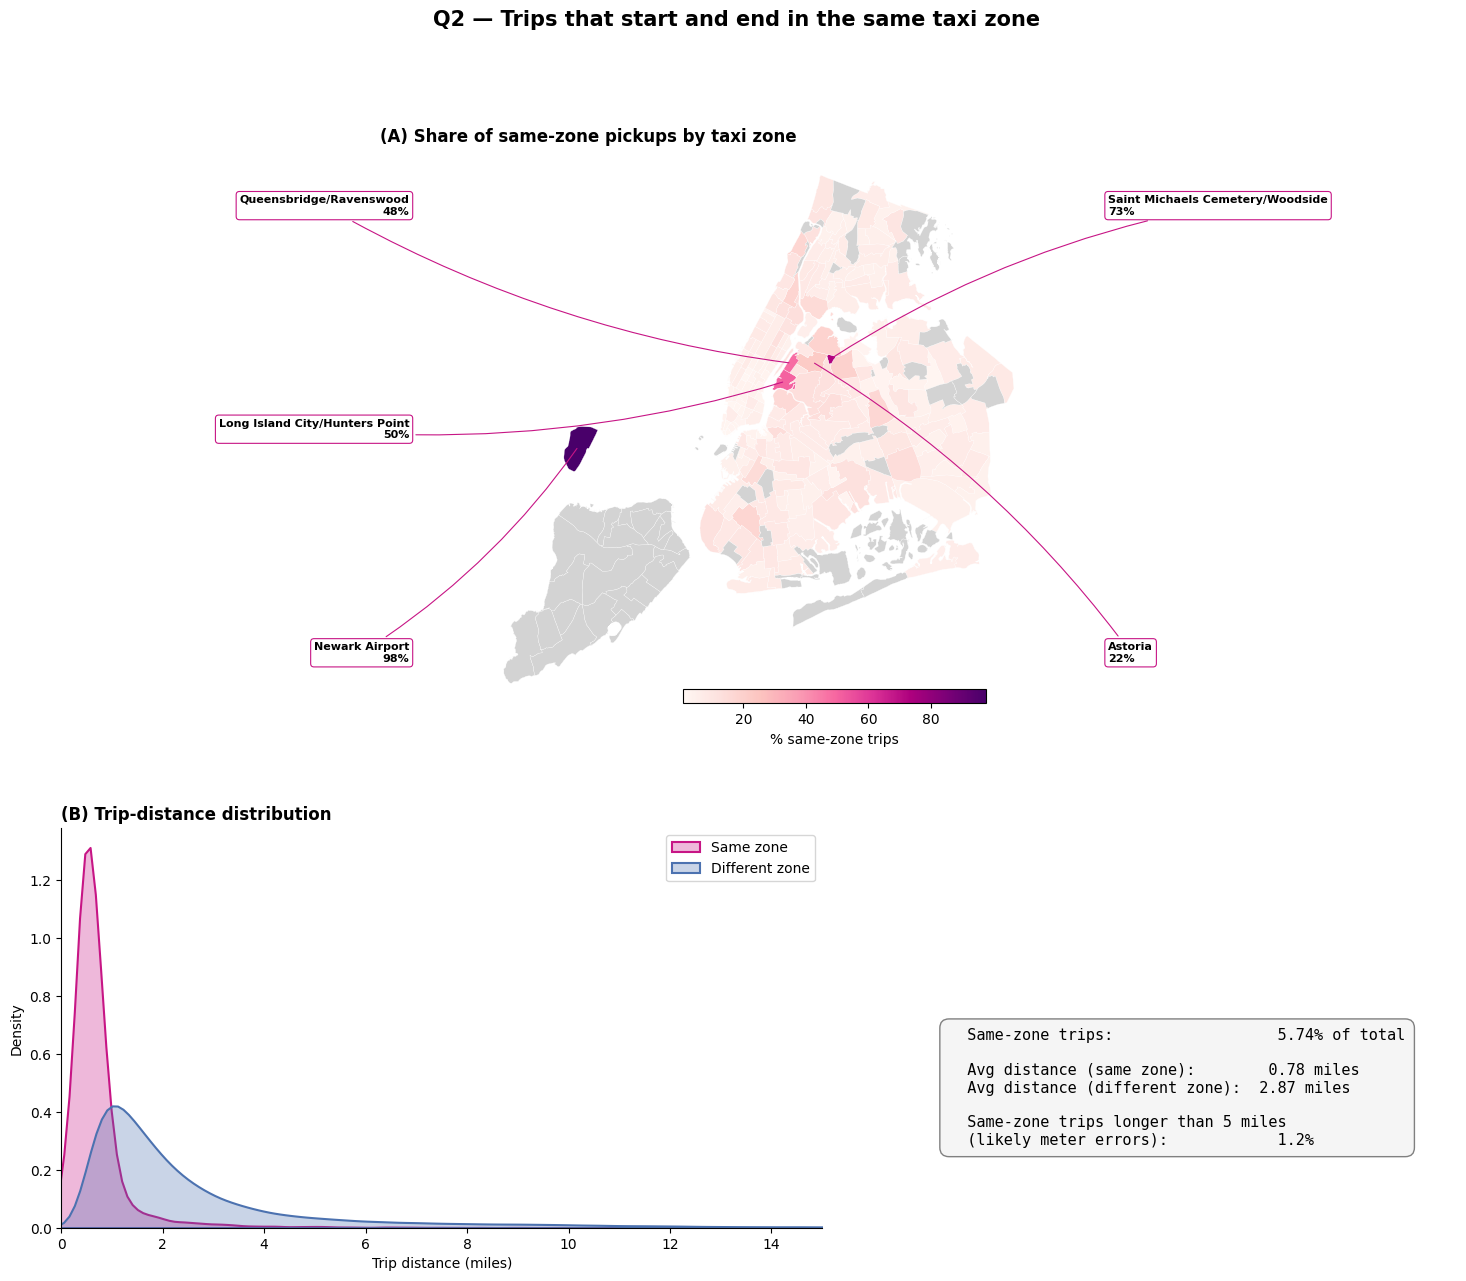

In [60]:
# Visualisation
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.4, 1],   # mapa ocupa mais espaço vertical
    width_ratios=[1.5, 1],    # distance plot é mais largo que a box
    hspace=0.25, wspace=0.2
)

# (A) Map: spans both columns of the top row
ax_map = fig.add_subplot(gs[0, :])
zones_q2 = zones_gdf.merge(
    q2_pd[["PULocationID", "pct_same_zone", "total_pickups"]],
    left_on="LocationID", right_on="PULocationID", how="left"
)
zones_q2.plot(
    column="pct_same_zone", cmap="RdPu",
    linewidth=0.2, edgecolor="white", ax=ax_map,
    legend=False,                      # <-- desligamos a legenda automática
    missing_kwds={"color": "lightgrey", "label": "Insufficient data"}
)

# Add colourbar manually, positioned to avoid the callout region
vmin = zones_q2["pct_same_zone"].min()
vmax = zones_q2["pct_same_zone"].max()
sm = ScalarMappable(cmap="RdPu", norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar_ax = ax_map.inset_axes([0.4, 0.01, 0.4, 0.025])  # x, y, width, height
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
             label="% same-zone trips")

# Top 5 zones with highest % same-zone — annotated as callouts on the map margins
top5_q2 = q2_pd.head(5).reset_index(drop=True).copy()
top5_q2["centroid"] = top5_q2["PULocationID"].map(
    lambda lid: zones_gdf.loc[
        zones_gdf["LocationID"] == lid, "centroid"
    ].iloc[0]
    if (zones_gdf["LocationID"] == lid).any() else None
)
top5_q2 = top5_q2.dropna(subset=["centroid"])
top5_q2["cx"] = top5_q2["centroid"].apply(lambda p: p.x)
top5_q2["cy"] = top5_q2["centroid"].apply(lambda p: p.y)

# Add padding to the map so the callouts have room
xmin, xmax = ax_map.get_xlim()
ymin, ymax = ax_map.get_ylim()
pad_x = (xmax - xmin) * 0.35
ax_map.set_xlim(xmin - pad_x * 0.5, xmax + pad_x * 0.5)

# Split into left/right based on longitude
median_x = top5_q2["cx"].median()
left  = top5_q2[top5_q2["cx"] <= median_x].sort_values("cy", ascending=False)
right = top5_q2[top5_q2["cx"] >  median_x].sort_values("cy", ascending=False)

x_left  = xmin - pad_x * 0.35
x_right = xmax + pad_x * 0.35

def label_positions(group, x_label):
    n = len(group)
    if n == 0:
        return []
    ys = np.linspace(ymax - (ymax - ymin) * 0.10,
                     ymin + (ymax - ymin) * 0.10, n)
    return list(zip([x_label] * n, ys, group.itertuples()))

placements = (
    label_positions(left,  x_left) +
    label_positions(right, x_right)
)

for label_x, label_y, row in placements:
    ha = "right" if label_x < median_x else "left"
    ax_map.annotate(
        f"{row.PU_Zone}\n{row.pct_same_zone:.0f}%",
        xy=(row.cx, row.cy),
        xytext=(label_x, label_y),
        fontsize=8, ha=ha, va="center", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", edgecolor="#C71585", linewidth=0.8),
        arrowprops=dict(arrowstyle="-",
                        color="#C71585", linewidth=0.8,
                        connectionstyle="arc3,rad=0.1")
    )

ax_map.set_title("(A) Share of same-zone pickups by taxi zone",
                 fontweight="bold", loc="left")
ax_map.set_axis_off()

# (B) Distance distribution: same-zone vs different-zone
ax_dist = fig.add_subplot(gs[1, 0])
for label, color in [("Same zone", "#C71585"),
                     ("Different zone", "#4C72B0")]:
    data = dist_sample[dist_sample["is_same_zone"] == label]["trip_distance"]
    sns.kdeplot(data, ax=ax_dist, label=label, color=color,
                fill=True, alpha=0.3, linewidth=1.5)
ax_dist.set_xlabel("Trip distance (miles)")
ax_dist.set_ylabel("Density")
ax_dist.set_title("(B) Trip-distance distribution",
                  fontweight="bold", loc="left")
ax_dist.set_xlim(0, 15)
ax_dist.legend(loc="upper right")
ax_dist.spines["top"].set_visible(False)
ax_dist.spines["right"].set_visible(False)

# (C) Numeric summary box
ax_summary = fig.add_subplot(gs[1, 1])
ax_summary.axis("off")

same_zone_pct  = 100 * same_zone_total / total_clean
same_zone_avg  = dist_sample[dist_sample["is_same_zone"] == "Same zone"]["trip_distance"].mean()
diff_zone_avg  = dist_sample[dist_sample["is_same_zone"] == "Different zone"]["trip_distance"].mean()
suspicious_long = (dist_sample[(dist_sample["is_same_zone"] == "Same zone") &
                               (dist_sample["trip_distance"] > 5)].shape[0]
                   / max(dist_sample[dist_sample["is_same_zone"] == "Same zone"].shape[0], 1)) * 100

summary_text = (
    f"  Same-zone trips:                  {same_zone_pct:.2f}% of total\n\n"
    f"  Avg distance (same zone):        {same_zone_avg:.2f} miles\n"
    f"  Avg distance (different zone):  {diff_zone_avg:.2f} miles\n\n"
    f"  Same-zone trips longer than 5 miles\n"
    f"  (likely meter errors):            {suspicious_long:.1f}%"
)
ax_summary.text(
    0.0, 0.5, summary_text,
    ha="left", va="top", family="monospace", fontsize=11,
    transform=ax_summary.transAxes,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="grey")
)

fig.suptitle("Q2 — Trips that start and end in the same taxi zone",
             fontsize=15, fontweight="bold", y=0.98)
plt.show()

Same-zone trips, though representing only a small fraction of total volume, exhibit an interesting bimodal pattern. Distance-wise, most are genuinely short, consistent with intra-neighbourhood rides in dense Manhattan zones. However, a non-trivial fraction extend beyond 5 miles, which is **physically inconsistent with staying in the same zone** and likely reflects metering errors, looping rides at airport queues, or aborted trips that were later resumed. The map also reveals airport zones (JFK, LaGuardia, EWR) with disproportionately high same-zone shares — a known artefact of taxi-stand cycling, where drivers re-engage the meter within the airport perimeter.

#### 4.2.3. Query 3 — Golden revenue routes

> *Which origin–destination pairs generated the highest accumulated revenue in 2020?*

We aggregate by O-D pair, summing `total_amount` and counting trips, and rank by total revenue. To frame the result, we also compute the **share of total revenue** captured by the top 15 routes — a standard concentration metric.

Cancellations are already excluded by the cleaning filter (`total_amount > 0`).

In [61]:
# Spark DataFrame API
q3_df = (
    taxi_clean
    .groupBy(
        "PULocationID", "PU_Zone", "PU_Borough",
        "DOLocationID", "DO_Zone", "DO_Borough"
    )
    .agg(
        _sum("total_amount").alias("total_revenue"),
        spark_count("*").alias("trip_count"),
        avg("total_amount").alias("avg_fare"),
    )
    .orderBy(col("total_revenue").desc())
    .limit(15)
)
q3_pd = q3_df.toPandas()

# Total revenue (for "share of total" annotation)
total_revenue = taxi_clean.agg(_sum("total_amount")).first()[0]
q3_pd["pct_of_total"] = q3_pd["total_revenue"] / total_revenue * 100

print(f"Total 2020 revenue: ${total_revenue/1e6:,.1f}M")
print(f"Top 15 routes share: {q3_pd['pct_of_total'].sum():.2f}% of total revenue")
print()
print(q3_pd[["PU_Zone", "DO_Zone", "total_revenue", "trip_count",
             "avg_fare", "pct_of_total"]].head(10).to_string(index=False))

Total 2020 revenue: $444.3M
Top 15 routes share: 3.72% of total revenue

                PU_Zone                   DO_Zone  total_revenue  trip_count   avg_fare  pct_of_total
  Upper East Side South     Upper East Side North     2002243.33      172803  11.586855      0.450653
  Upper East Side North     Upper East Side South     1758641.33      146659  11.991363      0.395824
  Upper East Side North     Upper East Side North     1439728.81      141973  10.140863      0.324045
  Upper East Side South     Upper East Side South     1311499.41      125441  10.455110      0.295184
         Central Harlem      Central Harlem North     1126570.20       14732  76.470961      0.253561
            JFK Airport Times Sq/Theatre District     1076928.78       15448  69.713153      0.242388
Queensbridge/Ravenswood   Queensbridge/Ravenswood     1068214.52        9391 113.748751      0.240427
      LaGuardia Airport Times Sq/Theatre District      948166.73       18818  50.386158      0.213407
    Linco

In [62]:
# Spark SQL
q3_sql = spark.sql("""
    SELECT
        PULocationID, PU_Zone, PU_Borough,
        DOLocationID, DO_Zone, DO_Borough,
        SUM(total_amount) AS total_revenue,
        COUNT(*)          AS trip_count,
        AVG(total_amount) AS avg_fare
    FROM taxi
    GROUP BY PULocationID, PU_Zone, PU_Borough,
             DOLocationID, DO_Zone, DO_Borough
    ORDER BY total_revenue DESC
    LIMIT 15
""")
q3_sql_pd = q3_sql.toPandas()

# Sanity check (totals should match within float precision)
assert abs(q3_pd["total_revenue"].sum() - q3_sql_pd["total_revenue"].sum()) < 1
print("✔ Both implementations match")

✔ Both implementations match


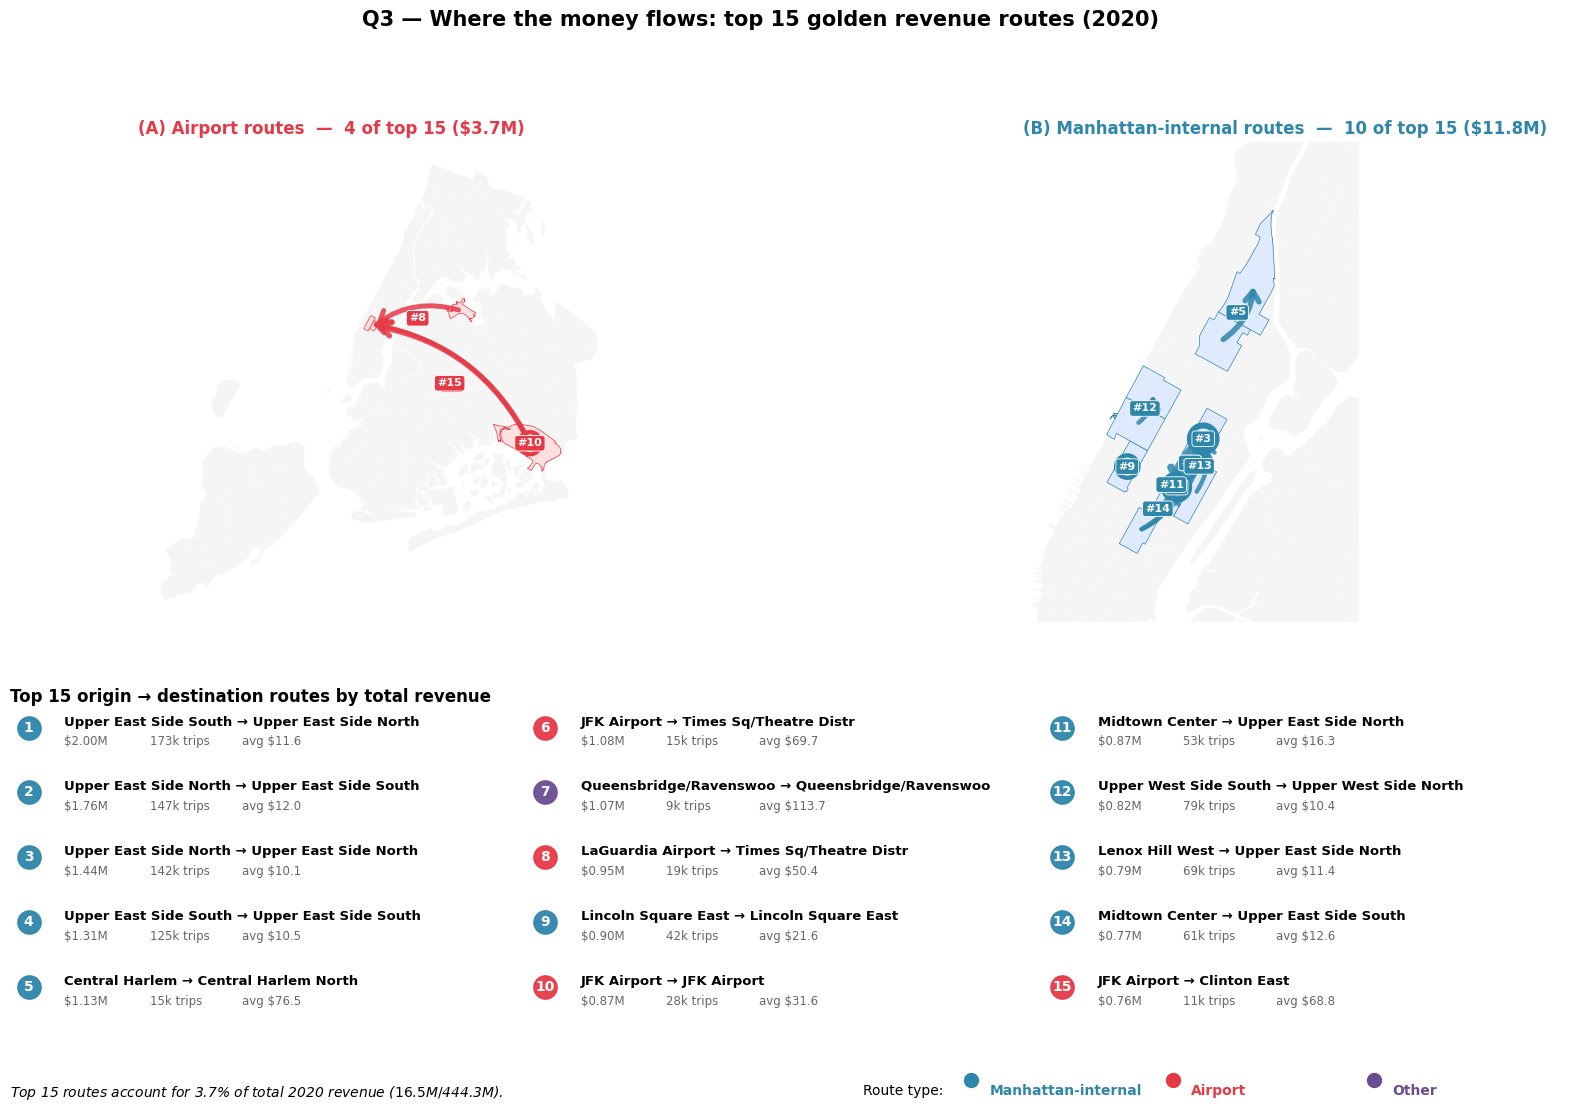

In [ ]:
# Visualisation: dual-map golden routes
q3_pd = q3_pd.reset_index(drop=True)
q3_pd["rank"] = q3_pd.index + 1

# Classify routes
AIRPORT_ZONES = {"JFK Airport", "LaGuardia Airport", "Newark Airport"}

def classify_route(row):
    if row["PU_Zone"] in AIRPORT_ZONES or row["DO_Zone"] in AIRPORT_ZONES:
        return "airport"
    if row["PU_Borough"] == "Manhattan" and row["DO_Borough"] == "Manhattan":
        return "manhattan"
    return "other"

q3_pd["route_type"] = q3_pd.apply(classify_route, axis=1)

# Centroids
all_zones_ids = set(q3_pd["PULocationID"]) | set(q3_pd["DOLocationID"])
centroids = {
    int(row["LocationID"]): row["centroid"]
    for _, row in zones_gdf[zones_gdf["LocationID"].isin(all_zones_ids)].iterrows()
}

# Color scheme
COLOR_MAP = {
    "manhattan": "#2E86AB",
    "airport":   "#E63946",
    "other":     "#6A4C93",
}

max_rev = q3_pd["total_revenue"].max()

def draw_route(ax, row, base_width=1.0):
    """Draw a single route arrow/self-loop with its rank badge."""
    pu_c = centroids.get(int(row["PULocationID"]))
    do_c = centroids.get(int(row["DOLocationID"]))
    if pu_c is None or do_c is None:
        return
    color = COLOR_MAP[row["route_type"]]
    width = base_width + 5.0 * (row["total_revenue"] / max_rev)
    label = f"#{int(row['rank'])}"   # use the ORIGINAL rank, always

    if row["PULocationID"] == row["DOLocationID"]:
        # Self-loop: open circle at the zone centroid
        ax.scatter(pu_c.x, pu_c.y,
                   s=400 * (row["total_revenue"] / max_rev) + 80,
                   facecolor="none", edgecolor=color,
                   linewidth=width * 0.9, zorder=10)
        ax.scatter(pu_c.x, pu_c.y, s=20, color=color, zorder=11)
        mx, my = pu_c.x, pu_c.y
    else:
        arrow = FancyArrowPatch(
            (pu_c.x, pu_c.y), (do_c.x, do_c.y),
            connectionstyle="arc3,rad=0.25",
            arrowstyle="->,head_width=5,head_length=7",
            color=color, linewidth=width, alpha=0.85, zorder=10
        )
        ax.add_patch(arrow)
        # Label at midpoint
        mx = (pu_c.x + do_c.x) / 2
        my = (pu_c.y + do_c.y) / 2

    ax.annotate(label, xy=(mx, my),
                fontsize=8, ha="center", va="center",
                fontweight="bold", color="white", zorder=12,
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor=color, edgecolor="white", linewidth=0.6))

# --- Figure layout ---
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        width_ratios=[1, 1], height_ratios=[1, 0.75],
                        hspace=0.2, wspace=0.1)

# === (A) FULL NYC: airport routes only ===
ax_full = fig.add_subplot(gs[0, 0])
zones_gdf.plot(ax=ax_full, color="#f5f5f5", linewidth=0.15, edgecolor="white")

airport_routes = q3_pd[q3_pd["route_type"] == "airport"]
airport_zones_ids = set(airport_routes["PULocationID"]) | set(airport_routes["DOLocationID"])
zones_gdf[zones_gdf["LocationID"].isin(airport_zones_ids)].plot(
    ax=ax_full, color="#ffe0e0", edgecolor="#E63946", linewidth=0.5
)
for _, row in airport_routes.iterrows():
    draw_route(ax_full, row, base_width=1.2)

ax_full.set_title(
    f"(A) Airport routes  —  {len(airport_routes)} of top 15 "
    f"(${airport_routes['total_revenue'].sum()/1e6:.1f}M)",
    fontweight="bold", loc="left", color=COLOR_MAP["airport"]
)
ax_full.set_axis_off()

# === (B) MANHATTAN CORE ===
ax_man = fig.add_subplot(gs[0, 1])
zones_gdf.plot(ax=ax_man, color="#f5f5f5", linewidth=0.15, edgecolor="white")

manhattan_routes = q3_pd[q3_pd["route_type"] == "manhattan"]
manhattan_zones_ids = set(manhattan_routes["PULocationID"]) | set(manhattan_routes["DOLocationID"])
zones_gdf[zones_gdf["LocationID"].isin(manhattan_zones_ids)].plot(
    ax=ax_man, color="#e0eaff", edgecolor="#2E86AB", linewidth=0.5
)
for _, row in manhattan_routes.iterrows():
    draw_route(ax_man, row, base_width=1.2)

# Zoom: use the bounds of the top-15 Manhattan zones, with padding
if len(manhattan_zones_ids) > 0:
    manhattan_zone_polys = zones_gdf[zones_gdf["LocationID"].isin(manhattan_zones_ids)]
    minx, miny, maxx, maxy = manhattan_zone_polys.total_bounds
    pad_x_zoom = (maxx - minx) * 0.5
    pad_y_zoom = (maxy - miny) * 0.2
    ax_man.set_xlim(minx - pad_x_zoom, maxx + pad_x_zoom)
    ax_man.set_ylim(miny - pad_y_zoom, maxy + pad_y_zoom)

ax_man.set_title(
    f"(B) Manhattan-internal routes  —  {len(manhattan_routes)} of top 15 "
    f"(${manhattan_routes['total_revenue'].sum()/1e6:.1f}M)",
    fontweight="bold", loc="left", color=COLOR_MAP["manhattan"]
)
ax_man.set_axis_off()

# === (C) Ranked list (bottom, full width) ===
ax_list = fig.add_subplot(gs[1, :])
ax_list.axis("off")

ax_list.text(0.0, 1.05,
             "Top 15 origin → destination routes by total revenue",
             fontsize=12, fontweight="bold",
             transform=ax_list.transAxes, va="top")

n_cols = 3
rows_per_col = 5
col_width = 1.0 / n_cols
y0 = 0.92
dy = 0.18

for _, row in q3_pd.iterrows():
    rank_idx = int(row["rank"]) - 1
    col_idx = rank_idx // rows_per_col
    row_idx = rank_idx % rows_per_col
    x_base = col_idx * col_width
    y = y0 - row_idx * dy

    color = COLOR_MAP[row["route_type"]]

    # Rank badge (circle + number)
    ax_list.scatter(x_base + 0.012, y + 0.02,
                    s=280, color=color, alpha=0.95,
                    transform=ax_list.transAxes, clip_on=False, zorder=5)
    ax_list.text(x_base + 0.012, y + 0.02, f"{int(row['rank'])}",
                 fontsize=10, fontweight="bold", color="white",
                 ha="center", va="center", zorder=6,
                 transform=ax_list.transAxes)

    # Route name
    pu_short = row["PU_Zone"][:22]
    do_short = row["DO_Zone"][:22]
    ax_list.text(x_base + 0.035, y + 0.035,
                 f"{pu_short} → {do_short}",
                 fontsize=9.5, fontweight="bold",
                 transform=ax_list.transAxes, va="center")

    # Metrics
    ax_list.text(x_base + 0.035, y - 0.02,
                 f"${row['total_revenue']/1e6:.2f}M",
                 fontsize=8.5, color="#666",
                 transform=ax_list.transAxes, va="center")
    
    ax_list.text(x_base + 0.09, y - 0.02,
                 f"{row['trip_count']/1e3:,.0f}k trips",
                 fontsize=8.5, color="#666",
                 transform=ax_list.transAxes, va="center")
    
    ax_list.text(x_base + 0.15, y - 0.02,
                 f"avg ${row['avg_fare']:.1f}",
                 fontsize=8.5, color="#666",
                 transform=ax_list.transAxes, va="center")

# Footnote + legend
total_rev_top15 = q3_pd["total_revenue"].sum()
ax_list.text(
    0.0, -0.05,
    f"Top 15 routes account for {total_rev_top15/total_revenue*100:.1f}% "
    f"of total 2020 revenue (${total_rev_top15/1e6:,.1f}M / ${total_revenue/1e6:,.1f}M).",
    transform=ax_list.transAxes, fontsize=10, style="italic", va="top"
)

x_offset = 0.55
ax_list.text(x_offset, -0.05, "Route type:",
             transform=ax_list.transAxes, fontsize=10, va="top")
x_offset += 0.07
for label, color in [("Manhattan-internal", COLOR_MAP["manhattan"]),
                     ("Airport",            COLOR_MAP["airport"]),
                     ("Other",              COLOR_MAP["other"])]:
    ax_list.scatter(x_offset, -0.04, s=100, color=color,
                    transform=ax_list.transAxes, clip_on=False)
    ax_list.text(x_offset + 0.012, -0.05, label,
                 transform=ax_list.transAxes, fontsize=10,
                 color=color, fontweight="bold", va="top")
    x_offset += 0.13

fig.suptitle("Q3 — Where the money flows: top 15 golden revenue routes (2020)",
             fontsize=15, fontweight="bold", y=0.99)
plt.show()

The revenue landscape is far more concentrated than mere trip counts suggest. Despite involving only 15 origin–destination pairs out of more than 50,000 theoretically possible combinations, the **top routes capture a substantial fraction of total revenue**, reflecting both higher average fares (long airport runs) and high frequency. The dominant flows connect Manhattan core zones to **JFK** and **LaGuardia airports**, in both directions, with self-loops at JFK (likely shuttle services within the terminal area) also appearing prominently. This pattern echoes the high `avg_fare` per route relative to the dataset average and frames the airport runs as the financial backbone of the 2020 yellow-taxi business — even during a pandemic year when overall demand collapsed.

#### 4.2.4. Geographic patterns — combined dashboard

The three queries are integrated into a single dashboard that summarises the geographic dimension of NYC Yellow Taxi 2020 demand: where pickups concentrate, where intra-zone trips occur and where revenue flows.

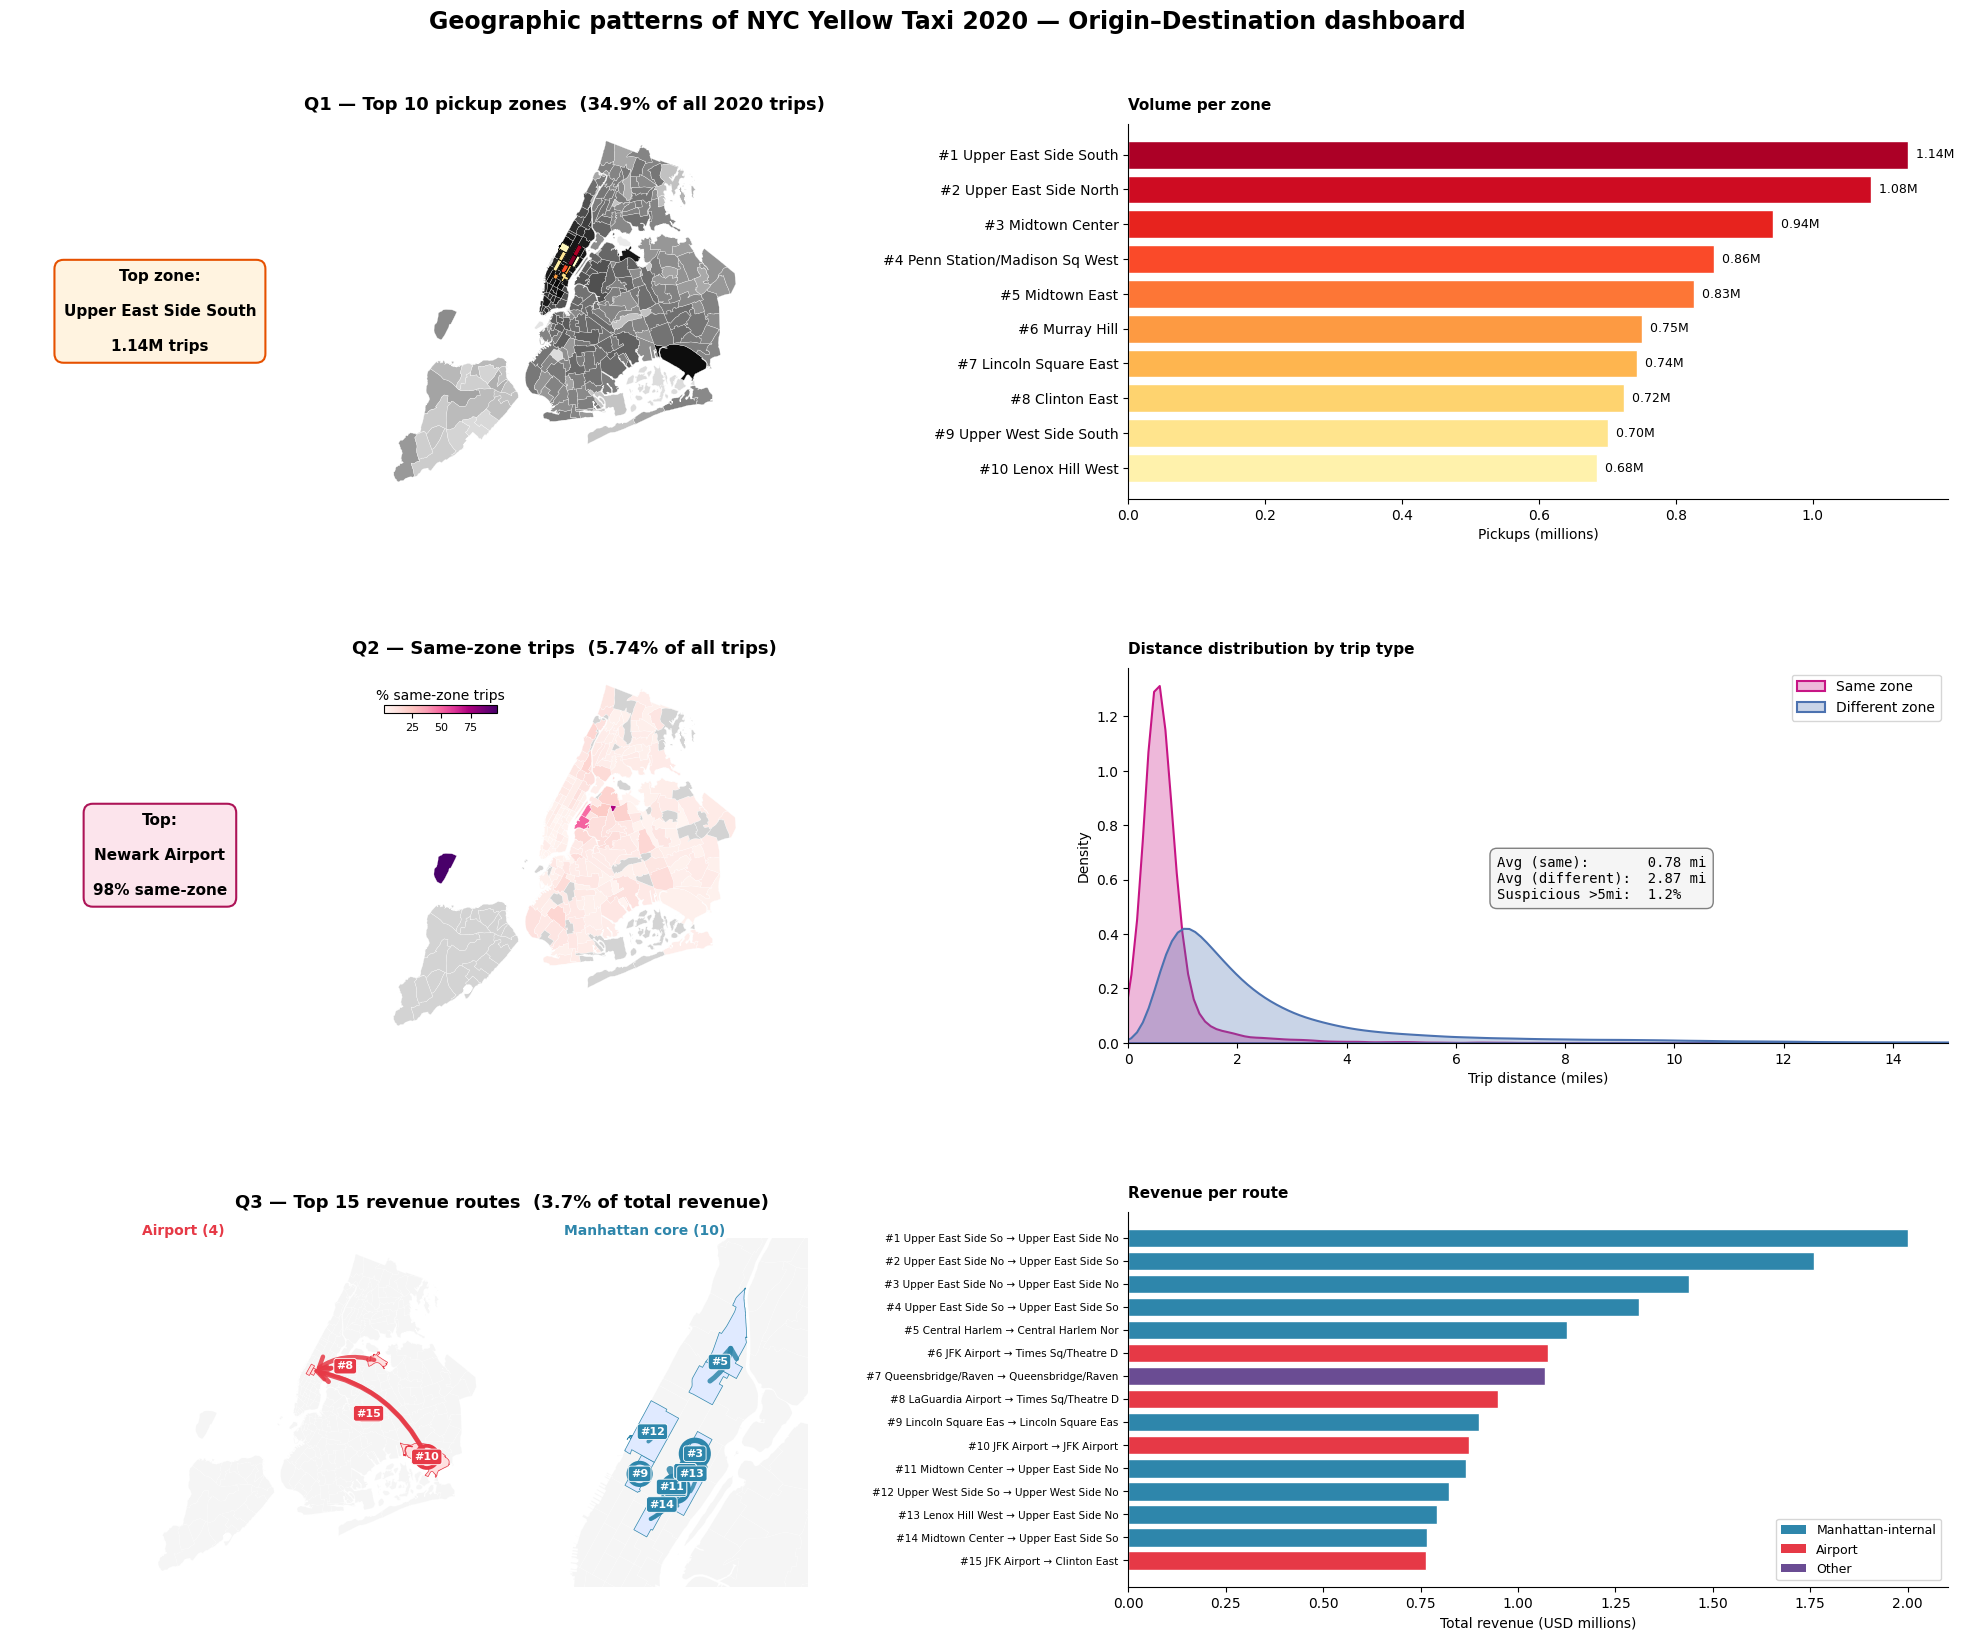

26/05/14 03:07:20 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 905029 ms exceeds timeout 120000 ms
26/05/14 03:07:20 WARN SparkContext: Killing executors is not supported by current scheduler.
26/05/14 03:07:20 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [105]:
fig = plt.figure(figsize=(25, 19))
gs  = gridspec.GridSpec(
    3, 2, figure=fig,
    height_ratios=[1, 1, 1],
    width_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.15
)

# ===================== Q1 ROW =====================
# Nested grid for left cell: [KPI box | Map]
gs_q1_left = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[0, 0],
    width_ratios=[0.35, 1], wspace=-0.3
)

# KPI box (left of the map)
ax_q1_kpi = fig.add_subplot(gs_q1_left[0])
ax_q1_kpi.axis("off")
ax_q1_kpi.text(
    0.5, 0.5,
    f"Top zone:\n\n{q1_pd.iloc[0]['PU_Zone']}\n\n{q1_pd.iloc[0]['pickups']/1e6:.2f}M trips",
    transform=ax_q1_kpi.transAxes,
    fontsize=11, fontweight="bold", va="center", ha="center",
    bbox=dict(boxstyle="round,pad=0.6",
              facecolor="#fff3e0", edgecolor="#e65100", linewidth=1.5)
)

# Map (right of KPI)
ax_q1_map = fig.add_subplot(gs_q1_left[1])
zones_q1.plot(column="pickups_log", cmap="Greys",
              linewidth=0.2, edgecolor="white", ax=ax_q1_map)
zones_q1[zones_q1["is_top10"]].plot(
    column="pickups_log", cmap="YlOrRd",
    linewidth=0.6, edgecolor="black", ax=ax_q1_map,
)
ax_q1_map.set_title(
    f"Q1 — Top 10 pickup zones  ({top10_share:.1f}% of all 2020 trips)",
    fontweight="bold", loc="center", fontsize=13, pad=10
)
ax_q1_map.set_axis_off()

# Q1 bars (unchanged)
ax_q1_bar = fig.add_subplot(gs[0, 1])
labels_q1 = [f"#{i+1} {z}" for i, z in enumerate(q1_pd["PU_Zone"])]
bars = ax_q1_bar.barh(labels_q1[::-1], q1_pd["pickups"][::-1] / 1e6,
                      color=sns.color_palette("YlOrRd_r", 10)[::-1],
                      edgecolor="white")
ax_q1_bar.set_xlabel("Pickups (millions)")
ax_q1_bar.set_title("Volume per zone", fontweight="bold",
                    loc="left", fontsize=11, pad=10)
ax_q1_bar.spines["top"].set_visible(False)
ax_q1_bar.spines["right"].set_visible(False)
for bar, v in zip(bars, q1_pd["pickups"][::-1]):
    ax_q1_bar.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                   f"  {v/1e6:.2f}M", va="center", fontsize=9)

# ===================== Q2 ROW =====================
# Nested grid for left cell: [KPI box | Map]
gs_q2_left = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[1, 0],
    width_ratios=[0.35, 1], wspace=-0.3
)

# KPI box (left of the map)
ax_q2_kpi = fig.add_subplot(gs_q2_left[0])
ax_q2_kpi.axis("off")
ax_q2_kpi.text(
    0.5, 0.5,
    f"Top:\n\n{q2_pd.iloc[0]['PU_Zone']}\n\n{q2_pd.iloc[0]['pct_same_zone']:.0f}% same-zone",
    transform=ax_q2_kpi.transAxes,
    fontsize=11, fontweight="bold", va="center", ha="center",
    bbox=dict(boxstyle="round,pad=0.6",
              facecolor="#fce4ec", edgecolor="#ad1457", linewidth=1.5)
)

# Map (right of KPI)
ax_q2_map = fig.add_subplot(gs_q2_left[1])
zones_q2.plot(
    column="pct_same_zone", cmap="RdPu",
    linewidth=0.2, edgecolor="white", ax=ax_q2_map,
    legend=False,
    missing_kwds={"color": "lightgrey"}
)
sm = ScalarMappable(cmap="RdPu", norm=Normalize(
    vmin=zones_q2["pct_same_zone"].min(),
    vmax=zones_q2["pct_same_zone"].max()
))
sm.set_array([])
cbar_ax = ax_q2_map.inset_axes([0.02, 0.88, 0.3, 0.02])
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
             label="% same-zone trips")
cbar_ax.xaxis.set_label_position("top")
cbar_ax.tick_params(labelsize=8)

ax_q2_map.set_title(
    f"Q2 — Same-zone trips  ({same_zone_pct:.2f}% of all trips)",
    fontweight="bold", loc="center", fontsize=13, pad=10
)
ax_q2_map.set_axis_off()

# Q2 density plot (unchanged)
ax_q2_dist = fig.add_subplot(gs[1, 1])
for label, color in [("Same zone", "#C71585"),
                     ("Different zone", "#4C72B0")]:
    data = dist_sample[dist_sample["is_same_zone"] == label]["trip_distance"]
    sns.kdeplot(data, ax=ax_q2_dist, label=label, color=color,
                fill=True, alpha=0.3, linewidth=1.5)
ax_q2_dist.set_xlabel("Trip distance (miles)")
ax_q2_dist.set_ylabel("Density")
ax_q2_dist.set_xlim(0, 15)
ax_q2_dist.set_title("Distance distribution by trip type",
                     fontweight="bold", loc="left", fontsize=11, pad=10)
ax_q2_dist.legend(loc="upper right", fontsize=10)
ax_q2_dist.spines["top"].set_visible(False)
ax_q2_dist.spines["right"].set_visible(False)
ax_q2_dist.text(
    0.45, 0.50,
    f"Avg (same):       {same_zone_avg:.2f} mi\n"
    f"Avg (different):  {diff_zone_avg:.2f} mi\n"
    f"Suspicious >5mi:  {suspicious_long:.1f}%",
    transform=ax_q2_dist.transAxes,
    fontsize=10, family="monospace", va="top",
    bbox=dict(boxstyle="round,pad=0.5",
              facecolor="#f5f5f5", edgecolor="grey")
)

# ===================== Q3 ROW =====================
gs_q3_left_wrapper = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs[2, 0],
    height_ratios=[0.05, 1], hspace=0.05    # <-- pequeno gap
)

# Title axes
ax_q3_title = fig.add_subplot(gs_q3_left_wrapper[0])
ax_q3_title.axis("off")
ax_q3_title.set_title(
    f"Q3 — Top 15 revenue routes  "
    f"({total_rev_top15/total_revenue*100:.1f}% of total revenue)",
    fontweight="bold", loc="center", fontsize=13, pad=0
)

# Two mini-maps
gs_q3_maps = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_q3_left_wrapper[1], wspace=-0.4
)

# Airport routes
ax_q3_air = fig.add_subplot(gs_q3_maps[0])
zones_gdf.plot(ax=ax_q3_air, color="#f5f5f5",
               linewidth=0.15, edgecolor="white")
zones_gdf[zones_gdf["LocationID"].isin(airport_zones_ids)].plot(
    ax=ax_q3_air, color="#ffe0e0",
    edgecolor=COLOR_MAP["airport"], linewidth=0.5
)
for _, row in airport_routes.iterrows():
    draw_route(ax_q3_air, row, base_width=0.8)
ax_q3_air.set_title(f"Airport ({len(airport_routes)})",
                    fontweight="bold", loc="left", fontsize=10,
                    color=COLOR_MAP["airport"], pad=-15)   # <-- pad negativo: cola ao mapa
ax_q3_air.set_axis_off()

# Manhattan routes
ax_q3_man = fig.add_subplot(gs_q3_maps[1])
zones_gdf.plot(ax=ax_q3_man, color="#f5f5f5",
               linewidth=0.15, edgecolor="white")
zones_gdf[zones_gdf["LocationID"].isin(manhattan_zones_ids)].plot(
    ax=ax_q3_man, color="#e0eaff",
    edgecolor=COLOR_MAP["manhattan"], linewidth=0.5
)
for _, row in manhattan_routes.iterrows():
    draw_route(ax_q3_man, row, base_width=0.8)
if len(manhattan_zones_ids) > 0:
    minx, miny, maxx, maxy = zones_gdf[
        zones_gdf["LocationID"].isin(manhattan_zones_ids)
    ].total_bounds
    px = (maxx - minx) * 0.5
    py = (maxy - miny) * 0.2
    ax_q3_man.set_xlim(minx - px, maxx + px)
    ax_q3_man.set_ylim(miny - py, maxy + py)
ax_q3_man.set_title(f"Manhattan core ({len(manhattan_routes)})",
                    fontweight="bold", loc="left", fontsize=10,
                    color=COLOR_MAP["manhattan"], pad=-15)   # <-- pad negativo
ax_q3_man.set_axis_off()

# Q3 bars (unchanged)
ax_q3_bar = fig.add_subplot(gs[2, 1])
route_labels = [f"#{int(r['rank'])} {r['PU_Zone'][:18]} → {r['DO_Zone'][:18]}"
                for _, r in q3_pd.iterrows()]
bar_colors = [COLOR_MAP[r["route_type"]] for _, r in q3_pd.iterrows()]
ax_q3_bar.barh(route_labels[::-1], q3_pd["total_revenue"][::-1] / 1e6,
               color=bar_colors[::-1], edgecolor="white")
ax_q3_bar.set_xlabel("Total revenue (USD millions)")
ax_q3_bar.set_title("Revenue per route", fontweight="bold",
                    loc="left", fontsize=11, pad=10)
ax_q3_bar.spines["top"].set_visible(False)
ax_q3_bar.spines["right"].set_visible(False)
ax_q3_bar.tick_params(axis="y", labelsize=7.5)

from matplotlib.patches import Patch
ax_q3_bar.legend(
    handles=[Patch(facecolor=c, label=l)
             for l, c in [("Manhattan-internal", COLOR_MAP["manhattan"]),
                          ("Airport",            COLOR_MAP["airport"]),
                          ("Other",              COLOR_MAP["other"])]],
    loc="lower right", fontsize=9, frameon=True
)

fig.suptitle(
    "Geographic patterns of NYC Yellow Taxi 2020 — Origin–Destination dashboard",
    fontsize=17, fontweight="bold", y=0.94
)
plt.show()

### **4.3. Temporal Dynamics**

...

### **4.4. Special Rates and Airports**

...

### **4.5. Efficiency and Operations**

...

---